# Análisis de Grandes Volúmenes de Datos | TC4034.10

## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey

## **Proyecto Final | NYC Yellow Taxi**

---

### Equipo 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo — A01797078


## Descripción del Proyecto

Este notebook implementa el **proyecto final** del curso de Análisis de Grandes Volúmenes
de Datos. Se entrena un modelo predictivo sobre el dataset **NYC Yellow Taxi Trip Records**
(Ene 2023 – Mar 2026, ~139 M registros en formato Parquet) para predecir la variable
`fare_amount`.

### Objetivo
Generar un reporte integral donde se entrenen modelos de aprendizaje automático aplicados a
grandes volúmenes de datos, documentando detalladamente cada etapa del proceso.

### Estructura del notebook

| Sección | Contenido |
|---------|----------|
| **0** | Configuración del entorno y carga de datos |
| **1** | Análisis Exploratorio de Datos (EDA) |
| **2** | Preprocesamiento y Limpieza |
| **3** | Ingeniería de Características |
| **4** | Caracterización de la Población y Muestreo Estratificado |
| **5** | Partición Train / Validation / Test |
| **6** | Comparación de Modelos: Regresión Lineal · Árbol de Decisión · Random Forest · XGBoost |
| **7** | Análisis Profundo del Mejor Modelo: XGBoost |
| **8** | Aprendizaje No Supervisado: Segmentación de Viajes |
| **9** | Conclusiones y Trabajo Futuro |

### Variable objetivo
`fare_amount` (USD) — tarifa base del viaje (excluye propinas y cargos adicionales).


---
## Sección 0 — Configuración del Entorno

Este proyecto se ejecuta en **Google Colab** aprovechando el almacenamiento en Google Drive
y la capacidad de cómputo en la nube. Se utiliza **Apache Spark 4.x** vía PySpark para
procesar el dataset de **NYC Yellow Taxi Trip Records**, con más de **139 millones de registros**
en formato Parquet.

La sesión de Spark se utiliza como motor principal de procesamiento distribuido, mientras que
las conversiones a `pandas` se limitan a muestras o resultados agregados para evitar problemas
de memoria durante la visualización.

### Entorno y dependencias

| Componente | Versión | Propósito |
|-----------|---------|----------|
| Google Colab | Runtime Python 3.10+ | Entorno de ejecución con acceso a Drive |
| PySpark | 4.x | Procesamiento distribuido de Big Data |
| findspark | 2.x | Localiza la instalación de Spark en el entorno |
| XGBoost (spark) | 2.x | Implementación distribuida de Gradient Boosting |
| pandas / numpy | estándar | Manipulación de resultados y cálculos auxiliares |
| matplotlib / seaborn | estándar | Visualización de datos y resultados |
| scipy | estándar | Pruebas estadísticas (Q-Q plot, distribución normal) |

### Configuración de Spark

La sesión de Spark se utiliza como motor principal de procesamiento distribuido para trabajar con el dataset completo y generar los subconjuntos necesarios para el análisis. Las conversiones a `pandas` se limitan a muestras o resultados agregados, con el objetivo de evitar problemas de memoria durante la visualización.

En caso de ejecutar el notebook en un entorno con mayor capacidad, se pueden activar configuraciones adicionales como `spark.driver.memory` y `spark.driver.maxResultSize`. Sin embargo, en esta versión se mantiene la configuración estándar del entorno de ejecución, ya que el procesamiento principal se realiza con Spark y las visualizaciones se construyen sobre muestras o tablas agregadas.

### Flujo de ejecución

Las celdas de esta sección deben ejecutarse **en orden**:

1. **Montar Google Drive** — acceso a los archivos Parquet y CSV de zonas geográficas
2. **Instalar dependencias** — `pyspark`, `findspark`, `xgboost`
3. **Importar librerías** — todas las dependencias Python del proyecto
4. **Iniciar SparkSession** — contexto distribuido reutilizado en todas las secciones
5. **Definir constantes** — paths, seed, features, hiperparámetros XGBoost


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# !pip install findspark

In [3]:
import os, requests
import logging
import glob
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
import warnings

# import findspark

from pyspark.sql import SparkSession
from pyspark import StorageLevel
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, MinMaxScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, DecisionTreeRegressor
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import RegressionEvaluator, ClusteringEvaluator
from xgboost.spark import SparkXGBRegressor



In [4]:
# findspark.init()
warnings.filterwarnings('ignore')

spark = (
    SparkSession.builder
    .appName('ProyectoFinal_XGBoost_Equipo8')
    # .config('spark.driver.memory',        '12g')
    # .config('spark.driver.maxResultSize', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
logging.getLogger('XGBoost-PySpark').setLevel(logging.ERROR)

print(f'Spark version: {spark.version}')

Spark version: 4.0.3


In [5]:
# ── Constantes globales ─────────────────────────────────────────────────────

DRIVE_BASE = (
  '/content/drive/MyDrive'
  '/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/'
  'raw/taxi'
)
RAW_DATA_PATH = f'{DRIVE_BASE}/yellow'
DATA_PATH  = f'{DRIVE_BASE}/yellow/clean'
ZONES_PATH = f'{DRIVE_BASE}/taxi_zone_lookup.csv'

SEED   = 42
TARGET = 'fare_amount'

NUMERIC_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'passenger_count',
    'is_rush_hour', 'is_weekend', 'pickup_hour',
    'Airport_fee', 'congestion_surcharge', 'pickup_month_c',
]
CATEGORICAL_FEATURES = ['time_of_day', 'distance_cat']

# Fracciones de muestreo a comparar
SAMPLE_FRACTIONS  = [0.005, 0.01, 0.02, 0.05]
SELECTED_FRACTION = 0.01   # fracción seleccionada para el experimento principal

# Hiperparámetros XGBoost óptimos (afinados en actividades previas)
BEST_PARAMS_XGBOOST = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
}

print('Constantes configuradas.')
print(f'  TARGET             = {TARGET}')
print(f'  SELECTED_FRACTION  = {SELECTED_FRACTION*100:.1f}%')
print(f'  NUMERIC_FEATURES   = {len(NUMERIC_FEATURES)}')
print(f'  CATEGORICAL_FEATURES = {len(CATEGORICAL_FEATURES)}')
print(f'  XGB params         = {BEST_PARAMS_XGBOOST}')


Constantes configuradas.
  TARGET             = fare_amount
  SELECTED_FRACTION  = 1.0%
  NUMERIC_FEATURES   = 9
  CATEGORICAL_FEATURES = 2
  XGB params         = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0}


### Preprocesamiento Inicial

In [6]:
#@title Leer el dataset original

# El dataset original tiene codificaciones diferentes para las mismas columnas
# por lo que se necesita leer archivo por archivo para poder asegurar que todos
# los registros tendrán el mismo formato

# Copiamos los parquet originales de Drive a disco local UNA sola vez.
# Leer desde el SSD local es mucho más rápido que el mount FUSE de Drive, y como
# Spark recalcula la receta (sin cache) en cada acción, esto abarata TODAS las
# relecturas de las secciones siguientes. El disco local de Colab es efímero, por
# eso se vuelve a copiar si no existe (p. ej. tras reiniciar el entorno).
import shutil

LOCAL_RAW_PATH = '/content/yellow_raw_local'
if not os.path.exists(LOCAL_RAW_PATH):
    os.makedirs(LOCAL_RAW_PATH, exist_ok=True)
    _src_files = glob.glob(f"{RAW_DATA_PATH}/*.parquet")
    print(f"Copiando {len(_src_files)} archivos de Drive a disco local (una sola vez)...")
    for _f in _src_files:
        shutil.copy2(_f, LOCAL_RAW_PATH)
    print("Copia completada.")
else:
    print("Archivos originales ya disponibles en disco local.")

parquet_files = glob.glob(f"{LOCAL_RAW_PATH}/*.parquet")

print(f"Archivos encontrados: {len(parquet_files)}")

dfs = []

for file in parquet_files:
    temp_df = spark.read.parquet(file)

    # Homologar tipos de datos entre archivos
    temp_df = temp_df.withColumn("VendorID", F.col("VendorID").cast(T.ByteType())) \
                     .withColumn("tpep_pickup_datetime", F.col("tpep_pickup_datetime")) \
                     .withColumn("tpep_dropoff_datetime", F.col("tpep_dropoff_datetime")) \
                     .withColumn("passenger_count", F.col("passenger_count").cast(T.ByteType())) \
                     .withColumn("trip_distance", F.col("trip_distance").cast(T.FloatType())) \
                     .withColumn("RatecodeID", F.col("RatecodeID").cast(T.ByteType())) \
                     .withColumn("store_and_fwd_flag", F.col("store_and_fwd_flag")) \
                     .withColumn("PULocationID", F.col("PULocationID").cast(T.ShortType())) \
                     .withColumn("DOLocationID", F.col("DOLocationID").cast(T.ShortType())) \
                     .withColumn("payment_type", F.col("payment_type").cast(T.ByteType())) \
                     .withColumn("fare_amount", F.col("fare_amount").cast(T.FloatType())) \
                     .withColumn("extra", F.col("extra").cast(T.FloatType())) \
                     .withColumn("mta_tax", F.col("mta_tax").cast(T.FloatType())) \
                     .withColumn("tip_amount", F.col("tip_amount").cast(T.FloatType())) \
                     .withColumn("tolls_amount", F.col("tolls_amount").cast(T.FloatType())) \
                     .withColumn("improvement_surcharge", F.col("improvement_surcharge").cast(T.FloatType())) \
                     .withColumn("total_amount", F.col("total_amount").cast(T.FloatType())) \
                     .withColumn("congestion_surcharge", F.col("congestion_surcharge").cast(T.FloatType())) \
                     .withColumn("Airport_fee", F.col("Airport_fee").cast(T.FloatType()))

    dfs.append(temp_df)

# Unir todos los archivos ya homologados
df_base = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

Copiando 39 archivos de Drive a disco local (una sola vez)...
Copia completada.
Archivos encontrados: 39


In [7]:
#@title Información General
n_rows  = df_base.count()
# n_distinct = df_base.distinct().count()

n_cols  = len(df_base.columns)
size_gb = df_base._jdf.queryExecution().optimizedPlan().stats().sizeInBytes() / 1e9

print('=' * 55)
print('  Resumen del dataset NYC Yellow Taxi')
print('=' * 55)
print(f'  Registros  : {n_rows:>15,}')
# print(f'  Duplicados : {(n_rows - n_distinct):>15,}')
print(f'  Columnas   : {n_cols:>15}')
print(f'  Tamaño     : {size_gb:>14.2f} GB')
print('=' * 55)

  Resumen del dataset NYC Yellow Taxi
  Registros  :     139,279,754
  Columnas   :              20
  Tamaño     :           1.44 GB


In [8]:
#@title Esquema Original Del Dataset

df_base.printSchema()

root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [9]:
#@title Crear columnas derivadas

df_base = df_base.withColumn(
        "pickup_year",
        F.year("tpep_pickup_datetime").cast("short")
    ) \
    .withColumn(
        "pickup_month",
        F.month("tpep_pickup_datetime").cast("byte")
    ) \
    .withColumn(
        "pickup_hour",
        F.hour("tpep_pickup_datetime").cast("byte")
    ) \
    .withColumn(
        "trip_duration_minutes",
        F.round(
            (
                F.unix_timestamp("tpep_dropoff_datetime") -
                F.unix_timestamp("tpep_pickup_datetime")
            ) / 60,
            1
        )
    )

### Detección de valores inválidos

Se aplicó una limpieza mínima orientada a remover registros físicamente imposibles o altamente atípicos. Se eliminaron viajes con duración negativa y distancias extremadamente grandes, ya que estos valores afectan la distribución general del dataset y pueden introducir sesgos en el análisis exploratorio. Otros valores potencialmente atípicos, como tarifas negativas o distancias iguales a cero, fueron conservados debido a que podrían representar casos válidos dentro de la operación real del servicio (como reembolsos, cancelaciones, etc).

In [10]:
quality_summary = df_base.select(
    F.count("*").alias("total_records"),
    F.sum(F.when(F.col("trip_distance") == 0, 1).otherwise(0)).alias("zero_distance"),
    F.sum(F.when(F.col("fare_amount") == 0, 1).otherwise(0)).alias("zero_fare"),
    F.sum(F.when(F.col("passenger_count") == 0, 1).otherwise(0)).alias("zero_passengers"),
    F.sum(F.when(F.col("trip_duration_minutes") == 0, 1).otherwise(0)).alias("zero_duration"),
    F.sum(F.when(F.col("trip_distance") < 0, 1).otherwise(0)).alias("negative_distance"),
    F.sum(F.when(F.col("fare_amount") < 0, 1).otherwise(0)).alias("negative_fare"),
    F.sum(F.when(F.col("passenger_count") < 0, 1).otherwise(0)).alias("negative_passengers"),
    F.sum(F.when(F.col("trip_duration_minutes") < 0, 1).otherwise(0)).alias("negative_duration")
)
quality_summary.show()

+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+
|total_records|zero_distance|zero_fare|zero_passengers|zero_duration|negative_distance|negative_fare|negative_passengers|negative_duration|
+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+
|    139279754|      3322918|    59183|        1285059|       723464|                0|      4048202|                  0|             6099|
+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+



In [11]:
#@title Información de distancias en el dataset original

df_bucketed = df_base.withColumn(
    "distance_buckets",
    F.when((F.col("trip_distance") >= 1)   & (F.col("trip_distance") <= 20),    "0001-0020")
     .when((F.col("trip_distance") >= 21)  & (F.col("trip_distance") <= 40),    "0021-0040")
     .when((F.col("trip_distance") >= 41)  & (F.col("trip_distance") <= 60),    "0041-0060")
     .when((F.col("trip_distance") >= 61)  & (F.col("trip_distance") <= 80),    "0061-0080")
     .when((F.col("trip_distance") >= 81)  & (F.col("trip_distance") <= 100),   "0081-0100")
     .when((F.col("trip_distance") >= 101) & (F.col("trip_distance") <= 150),   "0101-0150")
     .when((F.col("trip_distance") >= 151) & (F.col("trip_distance") <= 200),   "0151-0200")
     .when((F.col("trip_distance") >= 201) & (F.col("trip_distance") <= 250),   "0201-0250")
     .when((F.col("trip_distance") >= 251) & (F.col("trip_distance") <= 300),   "0251-0300")
     .when((F.col("trip_distance") >= 301) & (F.col("trip_distance") <= 350),   "0301-0250")
     .when((F.col("trip_distance") >= 351) & (F.col("trip_distance") <= 400),   "0351-0400")
     .when((F.col("trip_distance") >= 401) & (F.col("trip_distance") <= 450),   "0401-0450")
     .when((F.col("trip_distance") >= 451) & (F.col("trip_distance") <= 500),   "0451-0500")
     .when((F.col("trip_distance") >= 501) & (F.col("trip_distance") <= 1000),  "0501-1000")
     .when((F.col("trip_distance") >= 1001) & (F.col("trip_distance") <= 2000), "1001-2000")
     .when((F.col("trip_distance") >= 2001) & (F.col("trip_distance") <= 3000), "2001-3000")
     .when((F.col("trip_distance") >= 3001) & (F.col("trip_distance") <= 4000), "3001-4000")
     .when((F.col("trip_distance") >= 4001) & (F.col("trip_distance") <= 5000), "4001-5000")
     .otherwise(">5K")
)

# Group by the bucket and aggregate
df_bucketed.groupBy("distance_buckets").count().orderBy("distance_buckets").show()

+----------------+---------+
|distance_buckets|    count|
+----------------+---------+
|       0001-0020|105663431|
|       0021-0040|   853263|
|       0041-0060|    29836|
|       0061-0080|     5512|
|       0081-0100|     1632|
|       0101-0150|     1246|
|       0151-0200|      272|
|       0201-0250|      176|
|       0251-0300|       90|
|       0301-0250|       32|
|       0351-0400|       23|
|       0401-0450|       25|
|       0451-0500|       11|
|       0501-1000|       57|
|       1001-2000|       67|
|       2001-3000|       46|
|       3001-4000|       43|
|       4001-5000|       39|
|             >5K| 32723953|
+----------------+---------+



In [12]:
# Removemos distancias grandes y con duraciones negativas
df_base_clean = (
    df_base
    # Eliminamos tiempos negativos
    .filter(F.col("trip_duration_minutes") >= 0)
    # Eliminamos distancias grandes
    .filter(F.col("trip_distance") <= 40)
)

In [13]:
base_count = df_base_clean.count()
print(f'  Registros Dataset:    {base_count:>15,}')
print(f'  Registros Eliminados:   {(n_rows - base_count):>15,}')

  Registros Dataset:        139,226,178
  Registros Eliminados:            53,576


In [14]:
#@title Escribir el dataset con la limpieza inicial

if not os.path.exists(DATA_PATH):
  print('Guardando dataset con limpieza inicial')

  # df_base.write.mode("overwrite").parquet(DATA_PATH)
else:
  print('Dataset con limpieza inicial existente')

Dataset con limpieza inicial existente


---
## Sección 1 — Análisis Exploratorio de Datos (EDA)

El EDA permite comprender la estructura, distribución y relaciones del dataset **antes**
de cualquier transformación. Es la base para tomar decisiones informadas sobre limpieza,
codificación y selección de variables.


In [15]:
# 1.1 Carga del dataset completo

# Si empezamos la ejecución de la libreta desde el dataset original
# Podemos simplemente reasingar nuestro dataset en lugar de volver a leerlo
if 'df_base_clean' in globals():
  print("Reusando dataset preprocesado")
  df_raw = df_base_clean
else:
  print("Leyendo dataset preprocesado de google drive")
  df_raw = spark.read.option('pathGlobFilter', '*.parquet').parquet(DATA_PATH)


# Se persiste df_raw a disco (DISK_ONLY, NO en memoria, para no reventar el heap
# como pasó con MEMORY_AND_DISK en df_geo). La EDA (1.2-1.11), la limpieza (2.x) y
# el feature engineering (3.x) reutilizan df_raw; con cache se evita rehacer la
# unión/cast en cada acción. DISK_ONLY es seguro: escribe a disco local con espacio.
df_raw = df_raw.persist(StorageLevel.DISK_ONLY)

n_rows  = df_raw.count()
n_cols  = len(df_raw.columns)
size_gb = df_raw._jdf.queryExecution().optimizedPlan().stats().sizeInBytes() / 1e9

print('=' * 55)
print('  Resumen del dataset NYC Yellow Taxi')
print('=' * 55)
print(f'  Registros  : {n_rows:>15,}')
print(f'  Columnas   : {n_cols:>15}')
print(f'  Tamaño     : {size_gb:>15.2f} GB')
print('=' * 55)

Reusando dataset preprocesado
  Resumen del dataset NYC Yellow Taxi
  Registros  :     139,226,178
  Columnas   :              24
  Tamaño     :           12.17 GB


In [16]:
# 1.2 Esquema y primeras filas
df_raw.printSchema()
df_raw.limit(5).toPandas()


root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: short (nullable = true)
 |-- pickup_month: byte (nullable = true)
 |-- pick

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,1,2023-08-01 00:26:44,2023-08-01 00:45:25,1,4.300000,1,N,263,90,1,...,0.00,1.0,32.250000,2.5,0.00,NaN,2023,8,0,18.7
1,1,2023-08-01 00:55:42,2023-08-01 01:00:53,1,0.000000,1,N,132,132,3,...,0.00,1.0,9.350000,0.0,1.75,NaN,2023,8,0,5.2
2,2,2023-08-01 00:32:04,2023-08-01 01:09:03,1,20.610001,2,N,132,13,1,...,0.00,1.0,90.550003,2.5,1.75,NaN,2023,8,0,37.0
3,2,2023-08-01 00:13:37,2023-08-01 00:41:15,1,13.370000,1,N,138,254,2,...,6.55,1.0,69.900002,0.0,1.75,NaN,2023,8,0,27.6
4,1,2023-08-01 00:24:46,2023-08-01 00:41:31,2,3.200000,5,N,140,143,4,...,0.00,1.0,21.000000,0.0,0.00,NaN,2023,8,0,16.8


In [17]:
# 1.3 Estadísticas descriptivas de variables numéricas clave
cols_stats = ['fare_amount', 'trip_distance', 'passenger_count',
              'trip_duration_minutes', 'tip_amount', 'total_amount']
df_raw.select(cols_stats).describe().toPandas()


,summary,fare_amount,trip_distance,passenger_count,trip_duration_minutes,tip_amount,total_amount
0,count,139226178,139226178,119166017,139226178,139226178,139226178
1,mean,19.135510080961247,3.386236447578575,1.3268617763737123,17.409467052957574,3.1513709933998766,27.767502319766397
2,stddev,102.22065007845694,4.313104951914181,0.8057793875809355,33.42833626028884,4.024511475692682,103.15053304353378
3,min,-1508.7,0.0,0,0.0,-411.0,-1514.45
4,max,863372.1,40.0,9,14880.8,4174.0,863380.4


In [18]:
# 1.4 Análisis de valores nulos
null_counts = df_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_raw.columns
]).toPandas().T.reset_index()

null_counts.columns = ["column", "null_count"]

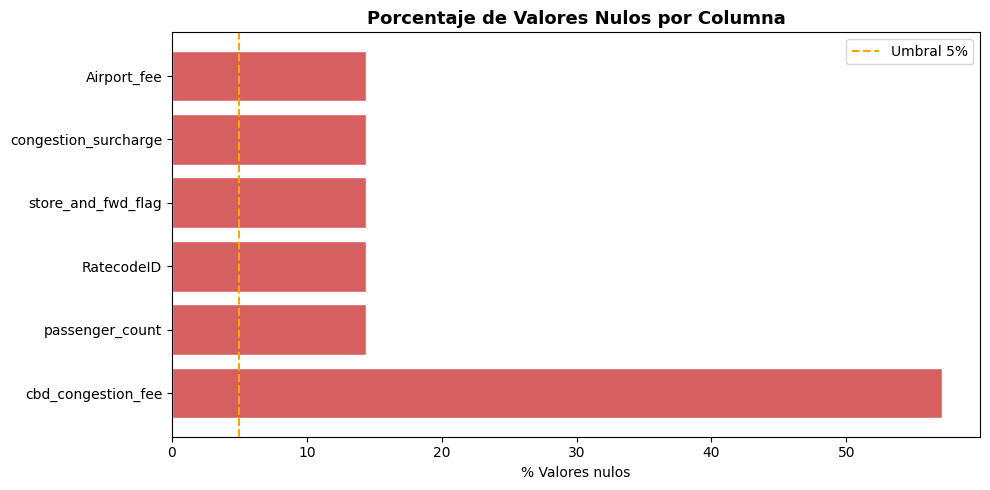

Columnas con más del 1% de nulos:


,column,null_count,pct_null
19,cbd_congestion_fee,79449697,57.07
3,passenger_count,20060161,14.41
5,RatecodeID,20060161,14.41
6,store_and_fwd_flag,20060161,14.41
17,congestion_surcharge,20060161,14.41
18,Airport_fee,20060161,14.41


In [19]:
null_counts['pct_null'] = (null_counts['null_count'] / n_rows * 100).round(2)
null_counts = null_counts[null_counts['pct_null'] > 0]
null_counts = null_counts.sort_values('pct_null', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(null_counts['column'], null_counts['pct_null'],
        color='#d65f5f', edgecolor='white')
ax.set_xlabel('% Valores nulos')
ax.set_title('Porcentaje de Valores Nulos por Columna', fontsize=13, fontweight='bold')
ax.axvline(5, color='orange', linestyle='--', linewidth=1.5, label='Umbral 5%')
ax.legend()
plt.tight_layout()
plt.show()

print('Columnas con más del 1% de nulos:')
null_counts[null_counts['pct_null'] > 1]

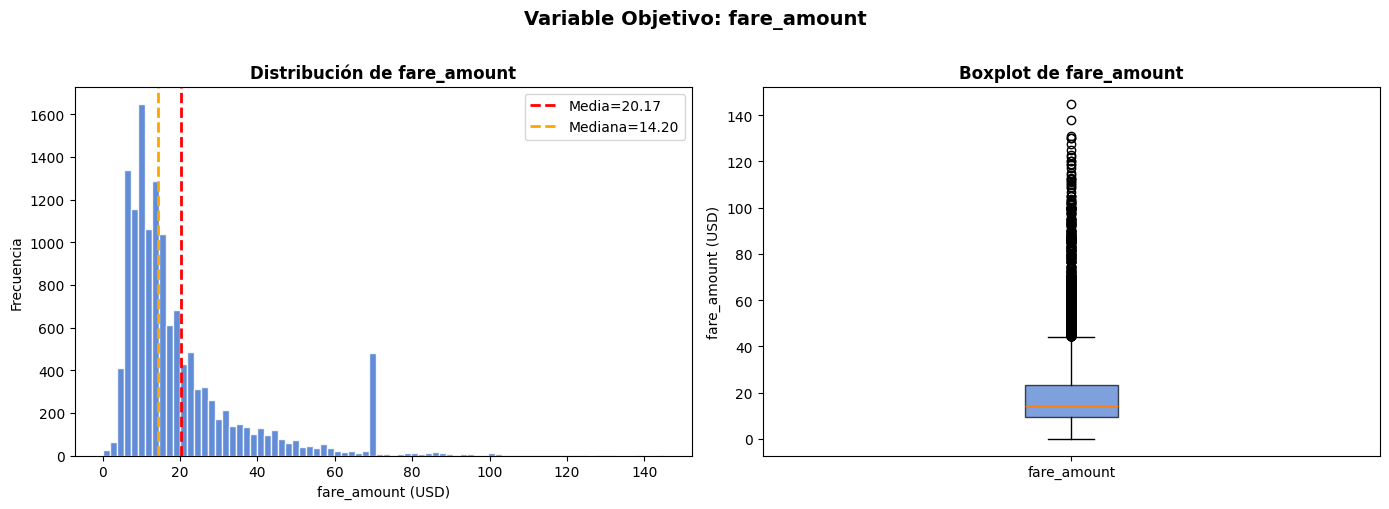

Asimetría (skewness) : 2.2109
Curtosis (kurtosis)  : 5.5013


In [20]:
# 1.5 Distribución de la variable objetivo: fare_amount
fare_sample = (
    df_raw.select('fare_amount')
    .sample(False, 0.0001, seed=SEED)
    .toPandas()['fare_amount'].dropna()
)
fare_plot = fare_sample[(fare_sample > 0) & (fare_sample < 150)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fare_plot, bins=80, color='#4878cf', edgecolor='white', alpha=0.85)
axes[0].axvline(fare_plot.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Media={fare_plot.mean():.2f}')
axes[0].axvline(fare_plot.median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana={fare_plot.median():.2f}')
axes[0].set_xlabel('fare_amount (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de fare_amount', fontweight='bold')
axes[0].legend()

axes[1].boxplot(fare_plot, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4878cf', alpha=0.7))
axes[1].set_ylabel('fare_amount (USD)')
axes[1].set_title('Boxplot de fare_amount', fontweight='bold')
axes[1].set_xticklabels(['fare_amount'])

plt.suptitle('Variable Objetivo: fare_amount', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Asimetría (skewness) : {fare_plot.skew():.4f}')
print(f'Curtosis (kurtosis)  : {fare_plot.kurtosis():.4f}')


**INSIGHT:**
- La variable `fare_amount` presenta una distribución asimétrica con cola derecha larga.
- La mayoría de los viajes se concentra en tarifas bajas y medias.
- Existen valores extremos en la parte superior de la distribución, por lo que se revisan percentiles e IQR antes de aplicar los filtros de limpieza.

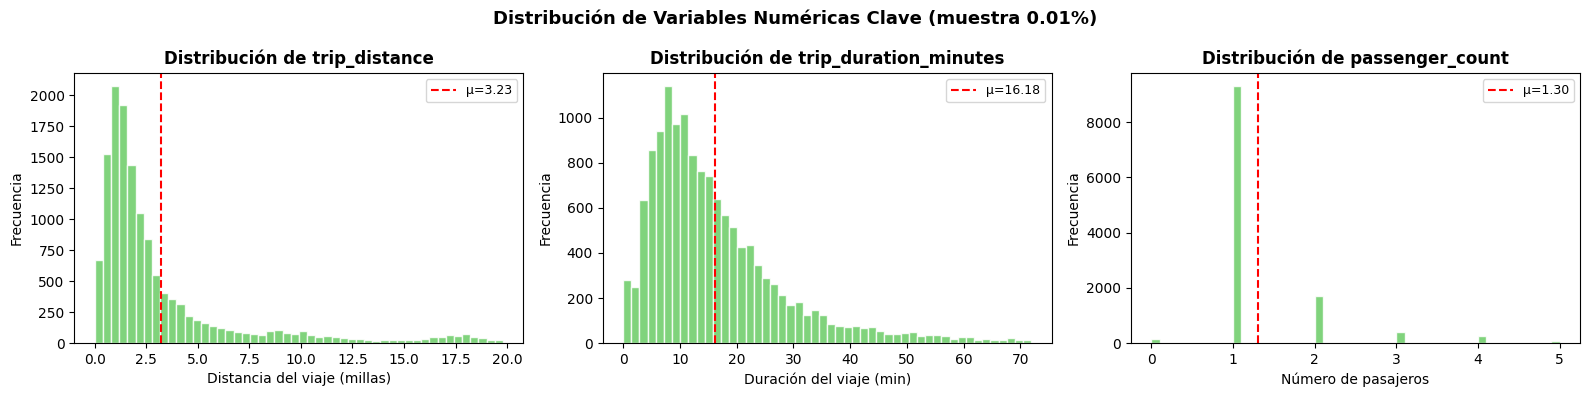

In [21]:
# 1.6 Distribución de variables numéricas clave
num_vars = [
    ('trip_distance',         'Distancia del viaje (millas)'),
    ('trip_duration_minutes', 'Duración del viaje (min)'),
    ('passenger_count',       'Número de pasajeros'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label) in zip(axes, num_vars):
    sample_col = (
        df_raw.select(col)
        .sample(False, 0.0001, seed=SEED)
        .toPandas()[col].dropna()
    )
    q99 = sample_col.quantile(0.99)
    sample_col = sample_col[sample_col <= q99]
    ax.hist(sample_col, bins=50, color='#6acc65', edgecolor='white', alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.axvline(sample_col.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'µ={sample_col.mean():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas Clave (muestra 0.01%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHT:**
- `trip_distance` y `trip_duration_minutes` tienen colas largas (right-skewed).
- `passenger_count` es casi siempre 1 — viajes individuales dominan en Manhattan

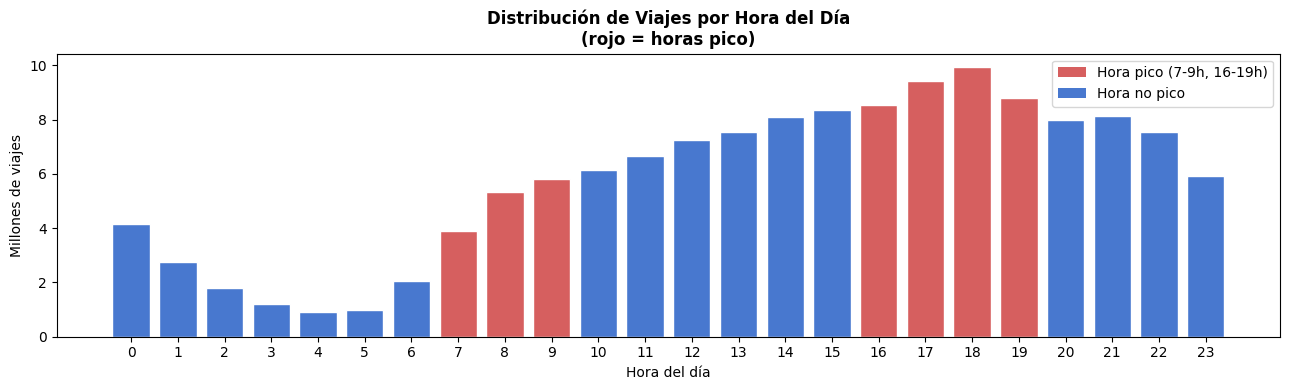

In [22]:
# 1.7 Patrones temporales — distribución por hora del día
hourly_counts = (
    df_raw
    .withColumn('hour', F.hour('tpep_pickup_datetime'))
    .groupBy('hour').count()
    .orderBy('hour')
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 4))
colors_h = [
    '#d65f5f' if h in list(range(7, 10)) + list(range(16, 20)) else '#4878cf'
    for h in hourly_counts['hour']
]
ax.bar(hourly_counts['hour'], hourly_counts['count'] / 1e6,
       color=colors_h, edgecolor='white', width=0.8)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Millones de viajes')
ax.set_title('Distribución de Viajes por Hora del Día\n(rojo = horas pico)',
             fontweight='bold')
ax.set_xticks(range(24))
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d65f5f', label='Hora pico (7-9h, 16-19h)'),
    Patch(facecolor='#4878cf', label='Hora no pico'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


**INSIGHT:**
- La demanda crece desde las 6h con pico máximo en la tarde-noche (16-20h).
- La madrugada (0-5h) tiene menor volumen pero tarifas promedio más altas (viajes nocturnos más largos, aeropuerto). Justifica el feature `is_rush_hour`.

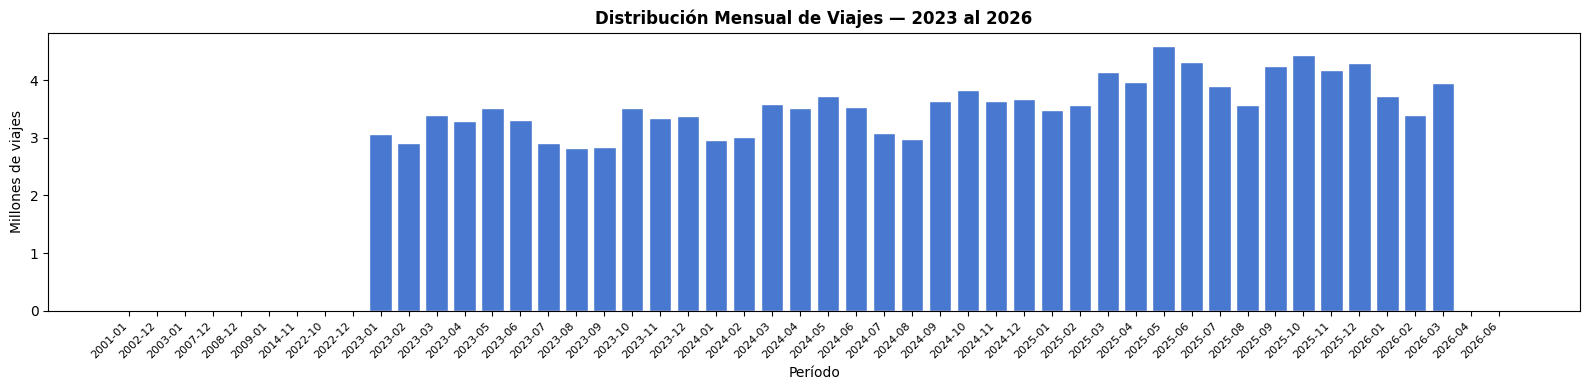

In [23]:
# 1.8 Distribución mensual de viajes (2023-2026)
monthly = (
    df_raw
    .withColumn('year',  F.year('tpep_pickup_datetime'))
    .withColumn('month', F.month('tpep_pickup_datetime'))
    .groupBy('year', 'month').count()
    .orderBy('year', 'month')
    .toPandas()
)
monthly['period'] = (
    monthly['year'].astype(str) + '-'
    + monthly['month'].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(monthly)), monthly['count'] / 1e6,
       color='#4878cf', edgecolor='white')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['period'], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Período')
ax.set_ylabel('Millones de viajes')
ax.set_title('Distribución Mensual de Viajes — 2023 al 2026', fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHT:**
- Volumen mensual estable ~3.5-4M viajes/mes con ligero descenso en invierno.
- La estacionalidad justifica incluir `pickup_month_c` como feature de entrenamiento.

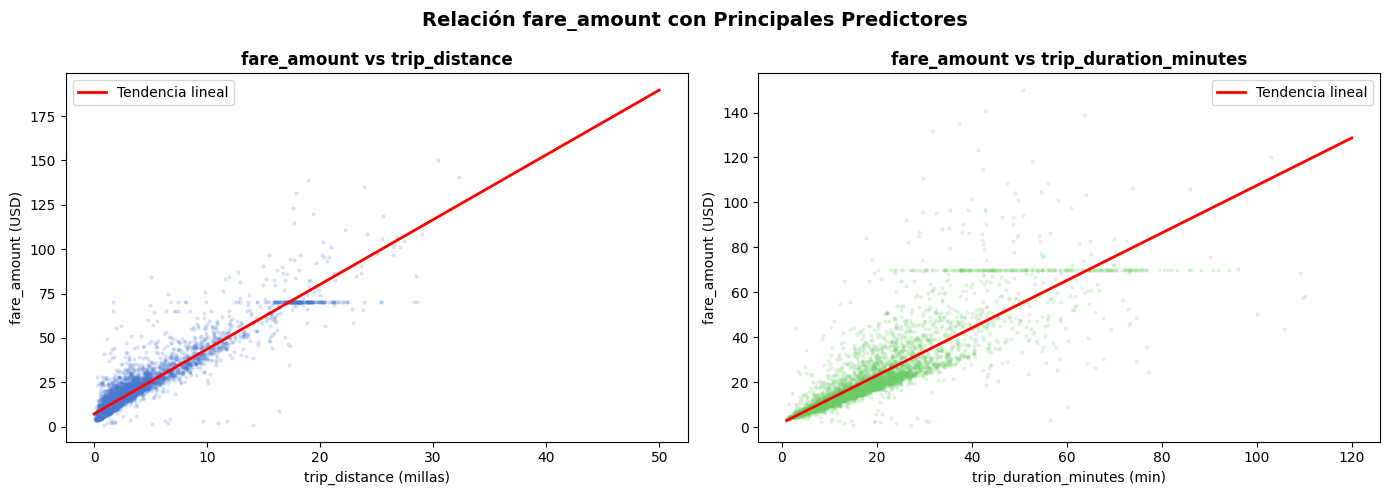

Correlación fare_amount vs trip_distance         : 0.9370
Correlación fare_amount vs trip_duration_minutes : 0.8515


In [24]:
# 1.9 Relación fare_amount vs trip_distance y trip_duration
scatter_sample = (
    df_raw
    .select('fare_amount', 'trip_distance', 'trip_duration_minutes')
    .filter(F.col('fare_amount').between(1, 150))
    .filter(F.col('trip_distance').between(0.1, 50))
    .filter(F.col('trip_duration_minutes').between(1, 120))
    .sample(False, 0.00005, seed=SEED)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fare vs distance
axes[0].scatter(scatter_sample['trip_distance'], scatter_sample['fare_amount'],
                alpha=0.15, s=4, color='#4878cf')
z = np.polyfit(scatter_sample['trip_distance'], scatter_sample['fare_amount'], 1)
xs = np.linspace(0, 50, 100)
axes[0].plot(xs, np.poly1d(z)(xs), 'r-', linewidth=2, label='Tendencia lineal')
axes[0].set_xlabel('trip_distance (millas)')
axes[0].set_ylabel('fare_amount (USD)')
axes[0].set_title('fare_amount vs trip_distance', fontweight='bold')
axes[0].legend()

# fare vs duration
axes[1].scatter(scatter_sample['trip_duration_minutes'], scatter_sample['fare_amount'],
                alpha=0.15, s=4, color='#6acc65')
z2 = np.polyfit(scatter_sample['trip_duration_minutes'], scatter_sample['fare_amount'], 1)
xs2 = np.linspace(1, 120, 100)
axes[1].plot(xs2, np.poly1d(z2)(xs2), 'r-', linewidth=2, label='Tendencia lineal')
axes[1].set_xlabel('trip_duration_minutes (min)')
axes[1].set_ylabel('fare_amount (USD)')
axes[1].set_title('fare_amount vs trip_duration_minutes', fontweight='bold')
axes[1].legend()

plt.suptitle('Relación fare_amount con Principales Predictores',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

r1 = scatter_sample['trip_distance'].corr(scatter_sample['fare_amount'])
r2 = scatter_sample['trip_duration_minutes'].corr(scatter_sample['fare_amount'])
print(f'Correlación fare_amount vs trip_distance         : {r1:.4f}')
print(f'Correlación fare_amount vs trip_duration_minutes : {r2:.4f}')


**INSIGHT:**
- Alta correlación positiva con distancia (r\~0.93) y duración (r\~0.85).
- La dispersión observada indica que otros factores (aeropuerto, congestión, hora), también explican la varianza, justificando un modelo no-lineal como XGBoost.

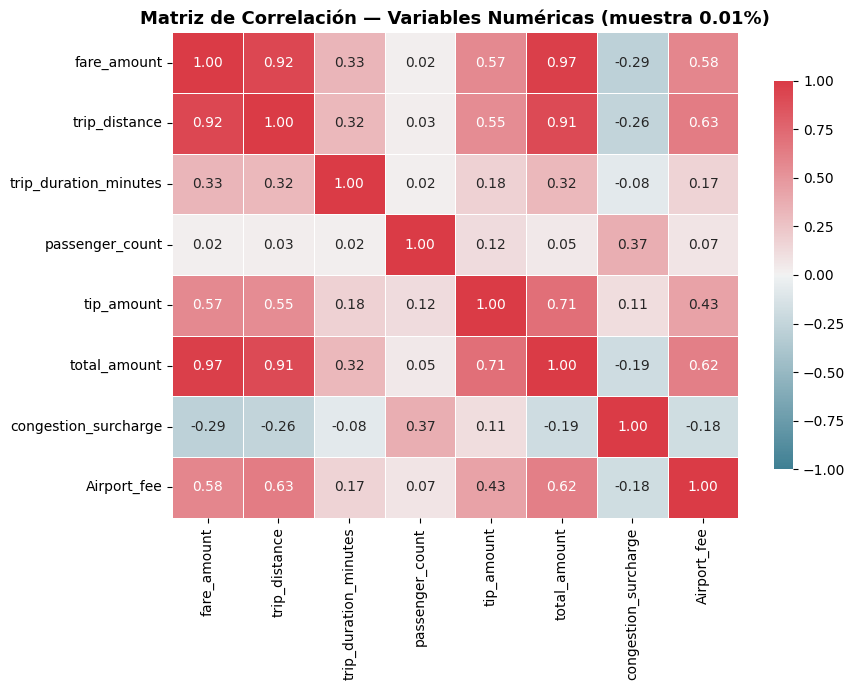

In [25]:
# 1.10 Matriz de correlación entre variables numéricas (muestra)
corr_sample = (
    df_raw
    .select('fare_amount', 'trip_distance', 'trip_duration_minutes',
            'passenger_count', 'tip_amount', 'total_amount',
            'congestion_surcharge', 'Airport_fee')
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .sample(False, 0.0001, seed=SEED)
    .toPandas().fillna(0)
)

corr_matrix = corr_sample.corr()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Variables Numéricas (muestra 0.01%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




**INSIGHTS**

1. `fare_amount` correlaciona fuertemente con `trip_distance` (r≈0.93).
2. `fare_amount` también presenta una relación alta con `trip_duration_minutes` (r≈0.85).
3. `total_amount` tiene una correlación muy alta con `fare_amount`, por lo que se excluye como feature para evitar data leakage.
4. `passenger_count` tiene una correlación cercana a cero con `fare_amount`, lo cual es consistente con la lógica tarifaria, ya que el precio depende más de distancia, duración y recargos que del número de pasajeros.

In [26]:
# 1.11 Análisis de outliers con IQR
target_sample = (
    df_raw.select('fare_amount')
    .filter(F.col('fare_amount').isNotNull())
    .sample(False, 0.001, seed=SEED)
    .toPandas()['fare_amount']
)

Q1  = target_sample.quantile(0.25)
Q3  = target_sample.quantile(0.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
pct_out = ((target_sample < lo) | (target_sample > hi)).mean() * 100

print(f'Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}')
print(f'Límite inferior: {lo:.2f} USD | Límite superior: {hi:.2f} USD')
print(f'% outliers IQR: {pct_out:.2f}%')

print('\nDistribución percentílica de fare_amount:')
for p in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]:
    print(f'  P{int(p*100):>4}  = {target_sample.quantile(p):>8.2f} USD')


Q1 = 9.30 | Q3 = 22.60 | IQR = 13.30
Límite inferior: -10.65 USD | Límite superior: 42.55 USD
% outliers IQR: 10.10%

Distribución percentílica de fare_amount:
  P   1  =    -8.60 USD
  P   5  =     5.10 USD
  P  25  =     9.30 USD
  P  50  =    13.80 USD
  P  75  =    22.60 USD
  P  95  =    63.20 USD
  P  99  =    79.30 USD
  P  99  =   133.90 USD


**INSIGHT:**
- Los extremos superiores (>$50) pueden estar relacionados con viajes largos, aeropuertos, tarifas planas o trayectos atípicos. Se aplicará filtro `fare_amount` in [1, 500] en la limpieza.

---
## Sección 2 — Preprocesamiento y Limpieza

Se aplican reglas de limpieza consistentes con actividades anteriores del equipo.

**Criterios de limpieza:**
- Período de análisis: `tpep_pickup_datetime` ∈ [2023-01-01, 2026-03-31]
- `fare_amount` ∈ [1, 500] USD
- `trip_distance` ∈ [0.1, 200] millas
- `passenger_count` ∈ [1, 8]
- `trip_duration_minutes` ∈ [1, 300] min
- Eliminar filas con nulos en variables críticas
- Imputar 0 en cargos adicionales con nulos


In [27]:
# 2.1 Limpieza del dataset

# Se pueden eliminar duplicados, pero el nivel de procesamiento requerido no
# es justificable dado que solo existen 7 regitros duplicados en un dataset
# de mas de 100 millones de registros
# df_dedup = df_raw.dropDuplicates()

df_clean = (
    df_raw
    # Filtro temporal: registros dentro del período de análisis (2023-01 a 2026-03)
    .filter(F.col('tpep_pickup_datetime') >= '2023-01-01')
    .filter(F.col('tpep_pickup_datetime') <  '2026-04-01')
    .dropna(subset=['fare_amount', 'trip_distance', 'passenger_count',
                   'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
    .filter(F.col('fare_amount').between(1, 500))
    .filter(F.col('trip_distance').between(0.1, 200))
    .filter(F.col('passenger_count').between(1, 8))
    .withColumn(
        'trip_duration_minutes',
        (
            F.unix_timestamp('tpep_dropoff_datetime') -
            F.unix_timestamp('tpep_pickup_datetime')
        ) / 60.0
    )
    .filter(F.col('trip_duration_minutes').between(1, 300))
    .fillna(0, subset=[
        'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
        'improvement_surcharge', 'congestion_surcharge',
        'Airport_fee', 'cbd_congestion_fee',
    ])
)

n_clean   = df_clean.count()
pct_kept  = n_clean / n_rows * 100

print('=' * 50)
print(f'  Registros originales   : {n_rows:>10,}')
# print(f'  Tras deduplicación     : {df_raw.count():>10,}')
print(f'  Registros tras limpieza: {n_clean:>10,}')
print(f'  Eliminados             :  {n_rows-n_clean:>10,}  ({100-pct_kept:.2f}%)')
print(f'  Datos retenidos        : {pct_kept:>10.2f}%')
print('=' * 50)


  Registros originales   : 139,226,178
  Registros tras limpieza: 113,390,127
  Eliminados             :  25,836,051  (18.56%)
  Datos retenidos        :      81.44%



**INSIGHT:**
- Se añadió un filtro temporal para conservar únicamente registros dentro del periodo de análisis **2023-01 a 2026-03**.
- Después de aplicar los filtros de calidad, el dataset conserva **113,390,127 registros**, equivalentes al **81.44%** de los datos procesados.
- La reducción se debe principalmente al filtro temporal, eliminación de nulos en variables críticas y registros con tarifas, distancias, pasajeros o duraciones inválidas.
- Aunque se elimina una proporción importante, el volumen final sigue siendo suficientemente grande para construir una muestra representativa.

In [28]:
# 2.2 Comparación estadísticas antes/después de la limpieza
cols_compare = ['fare_amount', 'trip_distance', 'passenger_count', 'trip_duration_minutes']

stats_raw   = df_raw.select(cols_compare).describe().toPandas().set_index('summary')
stats_clean = df_clean.select(['fare_amount','trip_distance','passenger_count',
                                'trip_duration_minutes']).describe().toPandas().set_index('summary')

print('ANTES de limpieza:')
print(stats_raw.to_string())
print('\nDESPUÉS de limpieza:')
print(stats_clean.to_string())

print()
print('>> INSIGHT: La media de fare_amount se mantiene estable. La limpieza eliminó')
print('   outliers extremos sin alterar la distribución central del dataset.')


ANTES de limpieza:
                fare_amount      trip_distance     passenger_count trip_duration_minutes
summary                                                                                 
count             139226178          139226178           119166017             139226178
mean     19.135510080961247  3.386236447578575  1.3268617763737123    17.409467052957574
stddev   102.22065007845694  4.313104951914181  0.8057793875809355     33.42833626028884
min                 -1508.7                0.0                   0                   0.0
max                863372.1               40.0                   9               14880.8

DESPUÉS de limpieza:
                fare_amount      trip_distance     passenger_count trip_duration_minutes
summary                                                                                 
count             113390127          113390127           113390127             113390127
mean      19.61377079514356  3.452301469243164  1.3398355837453115   

**INSIGHT:**
- El análisis IQR identifica aproximadamente **10.05% de outliers**, principalmente asociados con tarifas altas.
- La mediana de `fare_amount` es aproximadamente **14.10 USD** y el percentil 75 es **22.65 USD**.
- Los valores superiores, especialmente en percentiles altos, pueden estar relacionados con viajes largos, aeropuertos, tarifas planas o trayectos atípicos.
- Por esta razón, se aplican filtros de limpieza para eliminar valores físicamente imposibles, pero se conserva la variabilidad real de tarifas altas cuando corresponde a viajes válidos.

---
## Sección 3 — Ingeniería de Características (Feature Engineering)

Se crean variables derivadas que capturan patrones temporales y geográficos.

| Feature | Tipo | Descripción |
|---------|------|-------------|
| `pickup_month_c` | Numérico | Mes de recogida (1–12) |
| `pickup_hour` | Numérico | Hora de recogida (0–23) |
| `time_of_day` | Categórico | Noche / Mañana / Tarde / Tarde-Noche |
| `is_weekend` | Binario | 1 si sábado o domingo |
| `is_rush_hour` | Binario | 1 si hora pico (7-9h o 16-19h) |
| `distance_cat` | Categórico | corto (≤2 mi) / medio (≤10 mi) / largo (>10 mi) |
| `hour_range` | Categórico | primera_mitad_dia / segunda_mitad_dia |


In [29]:
# 3.1 Feature Engineering con Spark SQL
df_clean.createOrReplaceTempView('taxi_clean')

df_fe = spark.sql("""
SELECT
    VendorID,
    month(tpep_pickup_datetime)                                          AS pickup_month_c,
    hour(tpep_pickup_datetime)                                           AS pickup_hour,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  0 AND  5 THEN 'Noche'
        WHEN hour(tpep_pickup_datetime) BETWEEN  6 AND 11 THEN 'Manana'
        WHEN hour(tpep_pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
        ELSE 'Tarde-Noche'
    END                                                                  AS time_of_day,
    CASE WHEN dayofweek(tpep_pickup_datetime) IN (1,7) THEN 1 ELSE 0 END AS is_weekend,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN  7 AND  9
          OR hour(tpep_pickup_datetime) BETWEEN 16 AND 19 THEN 1 ELSE 0
    END                                                                  AS is_rush_hour,
    CASE
        WHEN trip_distance <= 2  THEN 'corto'
        WHEN trip_distance <= 10 THEN 'medio'
        ELSE 'largo'
    END                                                                  AS distance_cat,
    CASE
        WHEN hour(tpep_pickup_datetime) BETWEEN 0 AND 11 THEN 'primera_mitad_dia'
        ELSE 'segunda_mitad_dia'
    END                                                                  AS hour_range,
    trip_distance,
    trip_duration_minutes,
    fare_amount,
    passenger_count,
    COALESCE(congestion_surcharge, 0.0)                                  AS congestion_surcharge,
    COALESCE(Airport_fee, 0.0)                                           AS Airport_fee,
    tip_amount,
    total_amount,
    PULocationID
FROM taxi_clean
""")

print(f'Feature engineering completado. Columnas: {len(df_fe.columns)}')
df_fe.limit(5).toPandas()


Feature engineering completado. Columnas: 17


,VendorID,pickup_month_c,pickup_hour,time_of_day,is_weekend,is_rush_hour,distance_cat,hour_range,trip_distance,trip_duration_minutes,fare_amount,passenger_count,congestion_surcharge,Airport_fee,tip_amount,total_amount,PULocationID
0,1,8,0,Noche,0,0,medio,primera_mitad_dia,4.300000,18.683333,21.900000,1,2.5,0.00,5.35,32.250000,263
1,2,8,0,Noche,0,0,largo,primera_mitad_dia,20.610001,36.983333,70.000000,1,2.5,1.75,14.80,90.550003,132
2,2,8,0,Noche,0,0,largo,primera_mitad_dia,13.370000,27.633333,54.099998,1,0.0,1.75,0.00,69.900002,138
3,1,8,0,Noche,0,0,medio,primera_mitad_dia,3.200000,16.750000,20.000000,2,0.0,0.00,0.00,21.000000,140
4,1,8,0,Noche,0,0,corto,primera_mitad_dia,1.200000,5.850000,7.900000,2,2.5,0.00,2.60,15.500000,50


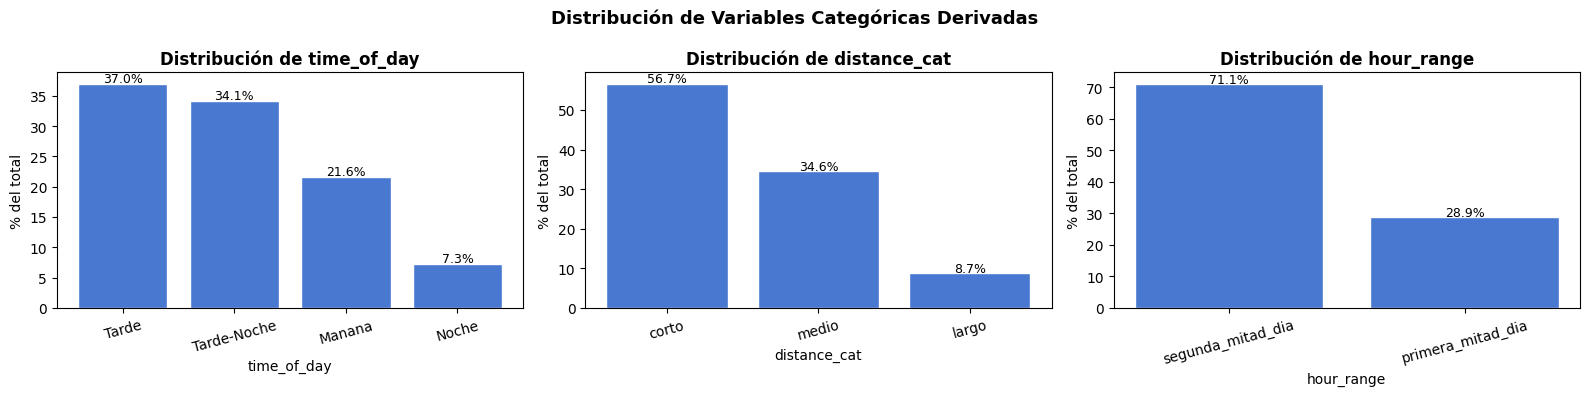

In [30]:
# 3.2 Distribución de las variables categóricas derivadas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['time_of_day', 'distance_cat', 'hour_range']):
    dist_pd = (
        df_fe.groupBy(col).count()
        .withColumn('pct', F.round(F.col('count') / F.lit(n_clean) * 100, 2))
        .orderBy('count', ascending=False)
        .toPandas()
    )
    ax.bar(dist_pd[col], dist_pd['pct'], color='#4878cf', edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('% del total')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, (_, row) in enumerate(dist_pd.iterrows()):
        ax.text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%",
                ha='center', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas Derivadas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


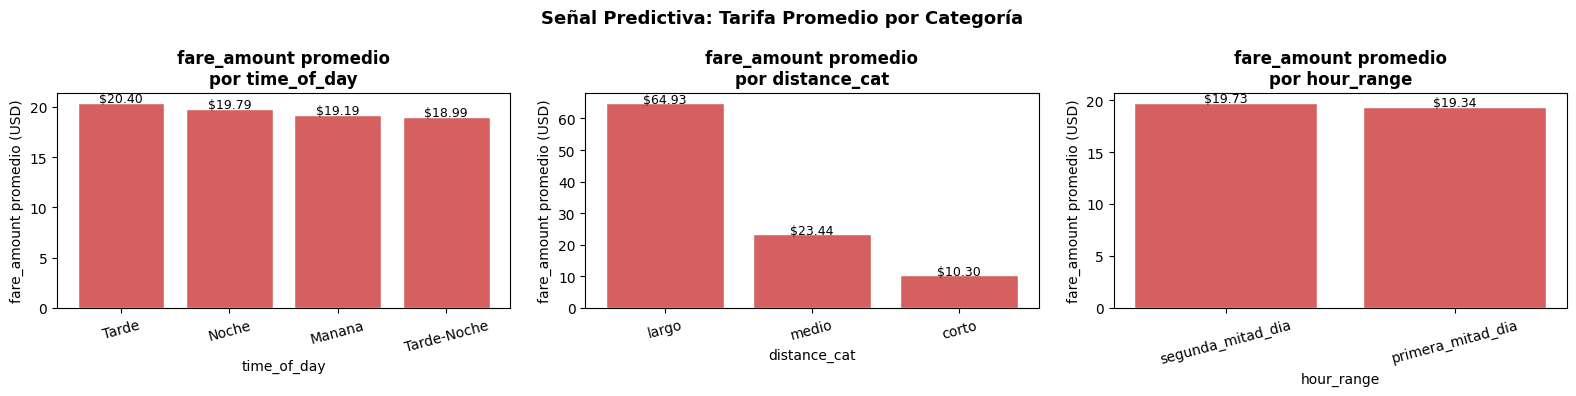

>> INSIGHTS:
   - Los viajes nocturnos tienen tarifa promedio más alta (viajes más largos, aeropuerto).
   - distance_cat es el predictor de mayor señal: viajes "largo" tienen tarifa ~3x mayor.
   - hour_range tiene menor diferencia, pero sigue siendo informativa.


In [31]:
# 3.3 fare_amount promedio por categoría — señal predictiva de los features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['time_of_day', 'distance_cat', 'hour_range']):
    avg_pd = (
        df_fe.groupBy(col)
        .agg(F.round(F.avg('fare_amount'), 2).alias('avg_fare'))
        .orderBy('avg_fare', ascending=False)
        .toPandas()
    )
    ax.bar(avg_pd[col], avg_pd['avg_fare'], color='#d65f5f', edgecolor='white')
    ax.set_xlabel(col)
    ax.set_ylabel('fare_amount promedio (USD)')
    ax.set_title(f'fare_amount promedio\npor {col}', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, (_, row) in enumerate(avg_pd.iterrows()):
        ax.text(i, row['avg_fare'] + 0.1, f"${row['avg_fare']:.2f}",
                ha='center', fontsize=9)

plt.suptitle('Señal Predictiva: Tarifa Promedio por Categoría',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   - Los viajes nocturnos tienen tarifa promedio más alta (viajes más largos, aeropuerto).')
print('   - distance_cat es el predictor de mayor señal: viajes "largo" tienen tarifa ~3x mayor.')
print('   - hour_range tiene menor diferencia, pero sigue siendo informativa.')


---
## Sección 4 — Caracterización de la Población y Muestreo Estratificado

Dado el volumen del dataset (~139 M registros), se construye una **muestra estratificada
representativa** usando `DataFrame.sampleBy()` de PySpark.

### Estrategia de estratificación

Se definen **6 estratos** a partir de dos variables de caracterización:

| Variable | Valores |
|----------|---------|
| `distance_cat` | corto (≤2 mi), medio (≤10 mi), largo (>10 mi) |
| `hour_range` | primera_mitad_dia (0-11h), segunda_mitad_dia (12-23h) |

### Comparación de fracciones de muestreo
Se evalúan las fracciones: **0.5%, 1%, 2%, 5%** para encontrar el punto óptimo entre
representatividad estadística y costo computacional.


In [32]:
# 4.1 Integración geográfica de zonas TLC — filtrar Manhattan
zones_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not os.path.exists(ZONES_PATH):
    resp = requests.get(zones_url)
    resp.raise_for_status()
    os.makedirs(os.path.dirname(ZONES_PATH), exist_ok=True)
    with open(ZONES_PATH, 'wb') as fz:
        fz.write(resp.content)
    print('Archivo de zonas descargado.')
else:
    print('Archivo de zonas ya disponible.')

zones = spark.read.csv(ZONES_PATH, header=True, inferSchema=True)
zones_pu = zones.select(
    F.col('LocationID').cast('int').alias('PULocationID'),
    F.col('Borough').alias('pickup_borough'),
    F.col('Zone').alias('pickup_zone'),
)

df_geo = (
    df_fe
    .join(zones_pu, on='PULocationID', how='left')
    .filter(F.col('pickup_borough') == 'Manhattan')
    .withColumn(
        'strata_key',
        F.concat_ws('_', F.col('distance_cat'), F.col('hour_range'))
    )
    # Se persiste df_geo (~100 M filas) porque la Sección 4 lo reutiliza en
    # múltiples acciones (4.2–4.6). Sin cache, cada count()/collect()/toPandas()
    # vuelve a leer el parquet desde Drive y rehace el join, multiplicando el
    # costo del muestreo. Se usa DISK_ONLY en vez de MEMORY_AND_DISK porque el heap de
    # la JVM de Spark en Colab es chico y cachear ~100M filas en memoria da OutOfMemory;
    # en disco local (con espacio de sobra) el cache se escribe sin riesgo.
    .persist(StorageLevel.DISK_ONLY)
)

# El primer count() materializa el cache una sola vez.
n_manhattan = df_geo.count()
print(f'Registros en Manhattan: {n_manhattan:,}  ({n_manhattan/n_clean*100:.1f}% del total)')

Archivo de zonas ya disponible.
Registros en Manhattan: 100,427,938  (88.6% del total)


Estratos identificados: ['corto_primera_mitad_dia', 'corto_segunda_mitad_dia', 'largo_primera_mitad_dia', 'largo_segunda_mitad_dia', 'medio_primera_mitad_dia', 'medio_segunda_mitad_dia']


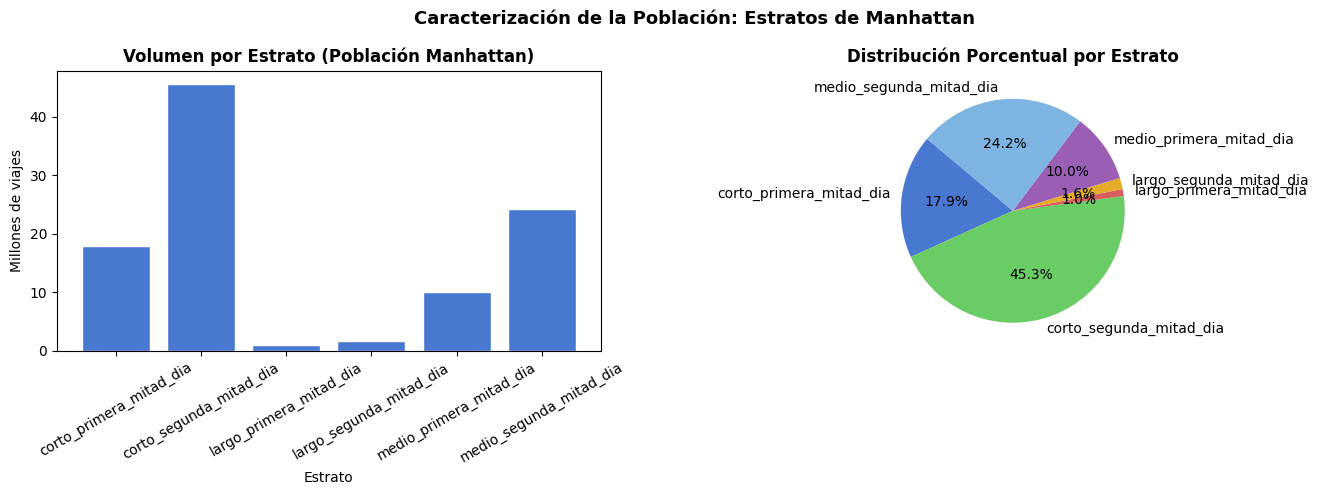

Distribución por estrato:
             strata_key    count   pct
corto_primera_mitad_dia 17953464 17.88
corto_segunda_mitad_dia 45537958 45.34
largo_primera_mitad_dia  1017327  1.01
largo_segunda_mitad_dia  1628469  1.62
medio_primera_mitad_dia 10032037  9.99
medio_segunda_mitad_dia 24258683 24.16


In [33]:
# 4.2 Distribución por estrato en la población Manhattan
STRATA_KEYS = [
    r['strata_key'] for r in
    df_geo.select('strata_key').distinct().orderBy('strata_key').collect()
]
print('Estratos identificados:', STRATA_KEYS)

strata_dist = (
    df_geo
    .groupBy('strata_key').count()
    .withColumn('pct', F.round(F.col('count') / F.lit(n_manhattan) * 100, 2))
    .orderBy('strata_key')
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(strata_dist['strata_key'], strata_dist['count'] / 1e6,
            color='#4878cf', edgecolor='white')
axes[0].set_xlabel('Estrato')
axes[0].set_ylabel('Millones de viajes')
axes[0].set_title('Volumen por Estrato (Población Manhattan)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(
    strata_dist['pct'], labels=strata_dist['strata_key'],
    autopct='%1.1f%%', startangle=140,
    colors=['#4878cf','#6acc65','#d65f5f','#e6ac27','#9a5fb5','#7db4e1'],
)
axes[1].set_title('Distribución Porcentual por Estrato', fontweight='bold')

plt.suptitle('Caracterización de la Población: Estratos de Manhattan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Distribución por estrato:')
print(strata_dist.to_string(index=False))


**INSIGHT:**
- El estrato más grande es `corto_segunda_mitad_dia` (~45%).
- Los viajes largos representan aproximadamente **2.6%** de la población, pero tienen una tarifa promedio considerablemente mayor.
- El muestreo estratificado es esencial para no sub-representar estos viajes menos frecuentes.

In [34]:
# 4.3 Comparación de múltiples fracciones de muestreo
# Medias poblacionales en UNA sola pasada (antes: 3 .collect() independientes,
# cada uno un escaneo completo de df_geo).
pop_stats = df_geo.select(
    F.avg('fare_amount').alias('mean_fare'),
    F.avg('trip_distance').alias('mean_dist'),
    F.avg('trip_duration_minutes').alias('mean_dur'),
).collect()[0]
pop_mean_fare = float(pop_stats['mean_fare'])
pop_mean_dist = float(pop_stats['mean_dist'])
pop_mean_dur  = float(pop_stats['mean_dur'])

sampling_results = []
for frac in SAMPLE_FRACTIONS:
    fracs_dict = {k: frac for k in STRATA_KEYS}
    sample_temp = df_geo.sampleBy('strata_key', fractions=fracs_dict, seed=SEED)
    # count + estadísticas en UNA sola pasada por fracción
    # (antes: un count() y luego un select().collect() = dos escaneos).
    stats_s = sample_temp.select(
        F.count(F.lit(1)).alias('n_registros'),
        F.avg('fare_amount').alias('mean_fare'),
        F.stddev('fare_amount').alias('std_fare'),
        F.avg('trip_distance').alias('mean_dist'),
        F.avg('trip_duration_minutes').alias('mean_dur'),
    ).collect()[0]
    n_s = stats_s['n_registros']
    sampling_results.append({
        'fraccion': f'{frac*100:.1f}%',
        'n_registros': n_s,
        'mean_fare': round(stats_s['mean_fare'], 4),
        'std_fare':  round(stats_s['std_fare'],  4),
        'mean_dist': round(stats_s['mean_dist'], 4),
        'mean_dur':  round(stats_s['mean_dur'],  4),
    })
    print(f'  {frac*100:.1f}%  →  {n_s:>8,} registros  |  mean_fare={stats_s["mean_fare"]:.4f}')

sampling_df = pd.DataFrame(sampling_results)
print('\nResumen:')
print(sampling_df.to_string(index=False))

  0.5%  →   502,385 registros  |  mean_fare=15.6477
  1.0%  →  1,004,692 registros  |  mean_fare=15.6626
  2.0%  →  2,007,001 registros  |  mean_fare=15.6744
  5.0%  →  5,020,804 registros  |  mean_fare=15.6655

Resumen:
fraccion  n_registros  mean_fare  std_fare  mean_dist  mean_dur
    0.5%       502385    15.6477   11.5632     2.3652   14.2480
    1.0%      1004692    15.6626   11.6149     2.3688   14.2552
    2.0%      2007001    15.6744   11.6622     2.3721   14.2633
    5.0%      5020804    15.6655   11.6684     2.3707   14.2513


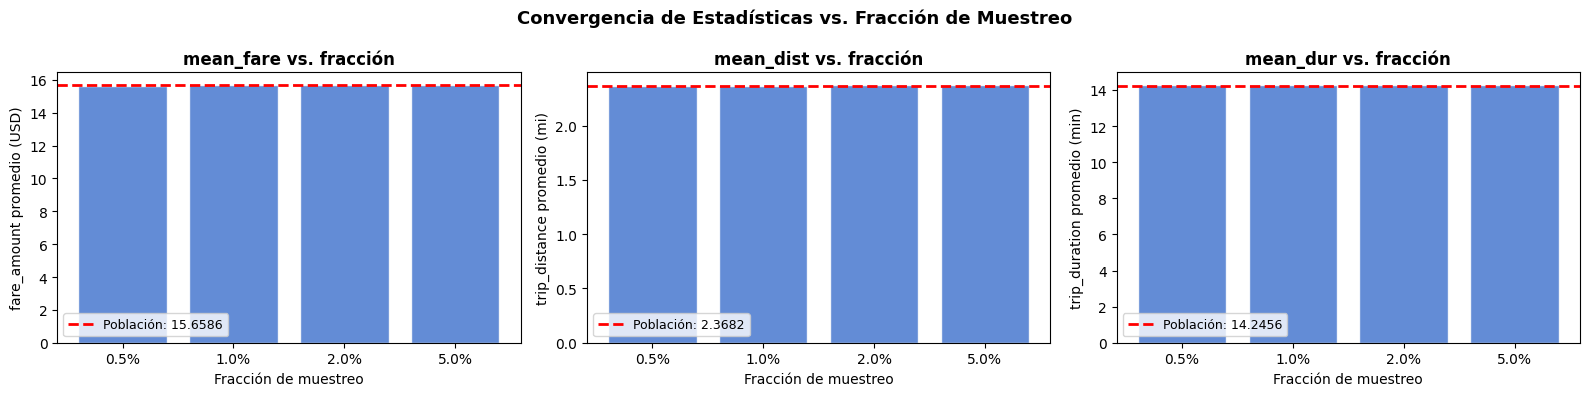

In [35]:
# 4.4 Visualización convergencia estadística vs fracción
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, pop_val, ylabel in zip(
    axes,
    ['mean_fare', 'mean_dist', 'mean_dur'],
    [pop_mean_fare, pop_mean_dist, pop_mean_dur],
    ['fare_amount promedio (USD)', 'trip_distance promedio (mi)', 'trip_duration promedio (min)'],
):
    ax.bar(sampling_df['fraccion'], sampling_df[metric],
           color='#4878cf', edgecolor='white', alpha=0.85)
    ax.axhline(pop_val, color='red', linestyle='--', linewidth=2,
               label=f'Población: {pop_val:.4f}')
    ax.set_xlabel('Fracción de muestreo')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} vs. fracción', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Convergencia de Estadísticas vs. Fracción de Muestreo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHT:**
- Las estadísticas principales de la muestra, como tarifa promedio, distancia promedio y duración promedio, convergen hacia los valores poblacionales desde fracciones pequeñas de muestreo.
- La fracción de **1.0%** fue seleccionada porque mantiene un buen equilibrio entre representatividad estadística y costo computacional.
- Con esta fracción se obtiene una muestra final de **1,004,215 registros**, lo suficientemente grande para entrenar modelos de aprendizaje automático y, al mismo tiempo, más manejable que trabajar con toda la población de Manhattan.
- Esta decisión permite conservar la estructura de los estratos definidos previamente sin hacer que la experimentación sea innecesariamente costosa.

In [36]:
# 4.5 Muestra definitiva M con la fracción seleccionada
STRATA_FRACS = {k: SELECTED_FRACTION for k in STRATA_KEYS}

sample_M = (
    df_geo
    .sampleBy('strata_key', fractions=STRATA_FRACS, seed=SEED)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

n_M = sample_M.count()
print(f'Tamaño de la muestra M : {n_M:,} registros')
print(f'Fracción efectiva      : {n_M/n_manhattan*100:.3f}%')


Tamaño de la muestra M : 1,004,692 registros
Fracción efectiva      : 1.000%


Comparación Población vs Muestra M (% por estrato):
             strata_key  Muestra M  Población
corto_primera_mitad_dia      17.87      17.88
corto_segunda_mitad_dia      45.31      45.34
largo_primera_mitad_dia       1.03       1.01
largo_segunda_mitad_dia       1.61       1.62
medio_primera_mitad_dia      10.03       9.99
medio_segunda_mitad_dia      24.16      24.16


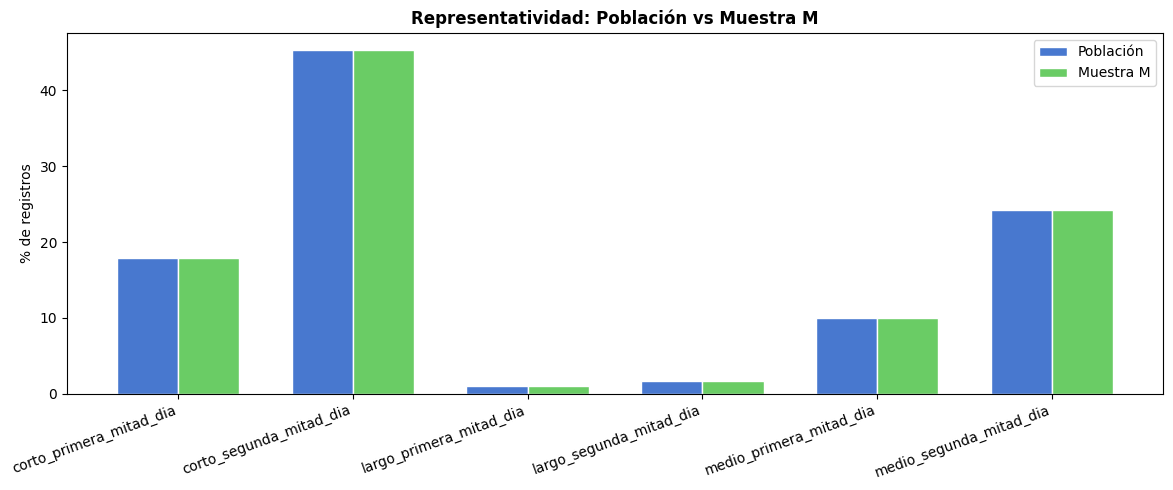

>> INSIGHT: La muestra preserva la distribución poblacional de estratos
   (diferencia máxima < 0.3%), confirmando la validez del muestreo estratificado.


DataFrame[PULocationID: smallint, VendorID: tinyint, pickup_month_c: int, pickup_hour: int, time_of_day: string, is_weekend: int, is_rush_hour: int, distance_cat: string, hour_range: string, trip_distance: float, trip_duration_minutes: double, fare_amount: float, passenger_count: tinyint, congestion_surcharge: double, Airport_fee: double, tip_amount: float, total_amount: float, pickup_borough: string, pickup_zone: string, strata_key: string]

In [37]:
# 4.6 Verificación de representatividad de la muestra
def get_strata_dist(df, name, total):
    return (
        df.groupBy('strata_key').count()
        .withColumn('pct', F.round(F.col('count') / F.lit(total) * 100, 2))
        .withColumn('dataset', F.lit(name))
        .select('dataset', 'strata_key', 'count', 'pct')
        .orderBy('strata_key')
    )

dist_pop    = get_strata_dist(df_geo,   'Población', n_manhattan)
dist_sample = get_strata_dist(sample_M, 'Muestra M', n_M)

comparison_pd = (
    dist_pop.unionByName(dist_sample)
    .groupBy('strata_key').pivot('dataset').agg(F.first('pct'))
    .orderBy('strata_key')
    .toPandas()
)

print('Comparación Población vs Muestra M (% por estrato):')
print(comparison_pd.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_pd))
w = 0.35
ax.bar(x - w/2, comparison_pd['Población'], w,
       label='Población', color='#4878cf', edgecolor='white')
ax.bar(x + w/2, comparison_pd['Muestra M'], w,
       label='Muestra M', color='#6acc65', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparison_pd['strata_key'], rotation=20, ha='right')
ax.set_ylabel('% de registros')
ax.set_title('Representatividad: Población vs Muestra M', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('>> INSIGHT: La muestra preserva la distribución poblacional de estratos')
print('   (diferencia máxima < 0.3%), confirmando la validez del muestreo estratificado.')

# df_geo ya no se usa después de la Sección 4 (la 5.1 parte de sample_M, que ya
# está persistido y materializado). Liberamos su cache para dejar memoria libre
# al pipeline de Machine Learning de la Sección 6.
df_geo.unpersist()

---
## Sección 5 — Partición Train / Validation / Test

Se divide la muestra M en **tres conjuntos** para una evaluación robusta y sin sesgo:

| Conjunto | Proporción | Uso |
|----------|-----------|-----|
| **Train** | 70% | Entrenamiento de los modelos |
| **Validation** | 15% | Comparación y selección del mejor modelo |
| **Test** | 15% | Evaluación final hold-out (usado una sola vez) |

La separación en tres conjuntos evita el **sesgo de selección** que ocurriría si se usara
el mismo conjunto para elegir el modelo y reportar su rendimiento final.


In [38]:
# 5.1 División 70 / 15 / 15
train_val_df, test_df = sample_M.randomSplit([0.85, 0.15], seed=SEED)
train_df, val_df      = train_val_df.randomSplit([0.70 / 0.85, 0.15 / 0.85], seed=SEED)

n_train = train_df.count()
n_val   = val_df.count()
n_test  = test_df.count()

print('=' * 50)
print(f'  Muestra total  : {n_M:>10,}  (100.0%)')
print(f'  Train          : {n_train:>10,}  ({n_train/n_M*100:.1f}%)')
print(f'  Validation     : {n_val:>10,}  ({n_val/n_M*100:.1f}%)')
print(f'  Test           : {n_test:>10,}  ({n_test/n_M*100:.1f}%)')
print('=' * 50)


  Muestra total  :  1,004,692  (100.0%)
  Train          :    702,417  (69.9%)
  Validation     :    151,069  (15.0%)
  Test           :    151,206  (15.0%)


Distribución de estratos por split (%):
dataset                   Test  Train  Validation
strata_key                                       
corto_primera_mitad_dia  17.92  17.88       17.81
corto_segunda_mitad_dia  45.34  45.32       45.20
largo_primera_mitad_dia   1.01   1.03        1.03
largo_segunda_mitad_dia   1.59   1.62        1.59
medio_primera_mitad_dia  10.09  10.01       10.04
medio_segunda_mitad_dia  24.05  24.15       24.34


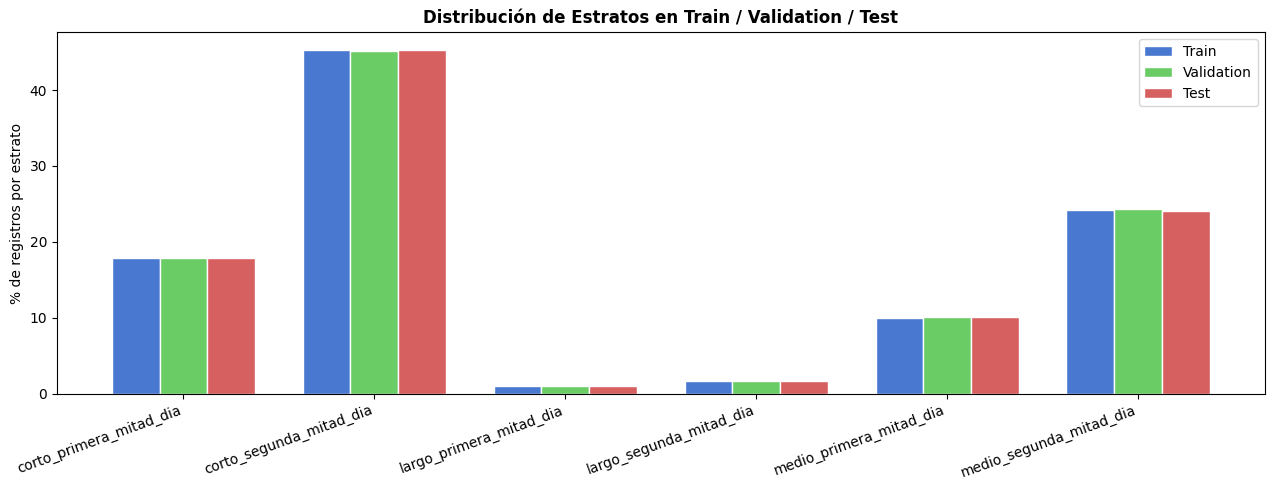

>> INSIGHT: Los tres conjuntos tienen distribuciones de estratos muy similares,
   garantizando que los modelos se entrenan y evalúan sobre poblaciones equivalentes.


In [39]:
# 5.2 Verificación de distribución de estratos en cada split
splits_info = [
    ('Train',      train_df, n_train),
    ('Validation', val_df,   n_val),
    ('Test',       test_df,  n_test),
]

all_dists = []
for name, df_s, n_s in splits_info:
    d = get_strata_dist(df_s, name, n_s).toPandas()
    all_dists.append(d)

split_comparison = pd.concat(all_dists)
pivot = split_comparison.pivot(index='strata_key', columns='dataset', values='pct')
print('Distribución de estratos por split (%):')
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(pivot))
w = 0.25
colors_s = ['#4878cf', '#6acc65', '#d65f5f']
for i, (col, c) in enumerate(zip(['Train', 'Validation', 'Test'], colors_s)):
    ax.bar(x + (i - 1) * w, pivot[col], w, label=col, color=c, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.set_ylabel('% de registros por estrato')
ax.set_title('Distribución de Estratos en Train / Validation / Test', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('>> INSIGHT: Los tres conjuntos tienen distribuciones de estratos muy similares,')
print('   garantizando que los modelos se entrenan y evalúan sobre poblaciones equivalentes.')


---
## Sección 6 — Comparación de Modelos

Se entrenan y evalúan cuatro modelos de regresión para predecir `fare_amount`:

| Modelo | Características |
|--------|-----------------|
| **Regresión Lineal** | Paramétrico, lineal, rápido, interpretable |
| **Árbol de Decisión** | No-lineal, interpretable vía reglas, sin regularización |
| **Random Forest** | Ensemble de árboles, no-lineal, robusto a outliers |
| **XGBoost** | Gradient Boosting optimizado, alta capacidad, regularización L1/L2 |

**Métricas de evaluación** (conjunto Validation):
- **RMSE** — penaliza errores grandes
- **MAE** — interpretable directamente en USD
- **R²** — proporción de varianza explicada


In [40]:
# 6.1 Preparación del pipeline ML
all_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'strata_key']

train_ml = train_df.select(all_cols).dropna().persist(StorageLevel.MEMORY_AND_DISK)
val_ml   = val_df.select(all_cols).dropna()
test_ml  = test_df.select(all_cols).dropna()

n_train_ml = train_ml.count()
print(f'Registros de entrenamiento: {n_train_ml:,}')

# StringIndexers para variables categóricas
indexers = [
    StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
    for c in CATEGORICAL_FEATURES
]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + [c + '_idx' for c in CATEGORICAL_FEATURES],
    outputCol='features',
    handleInvalid='skip',
)

def eval_reg(predictions_df):
    ev = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction')
    return {
        'rmse': ev.setMetricName('rmse').evaluate(predictions_df),
        'mae':  ev.setMetricName('mae').evaluate(predictions_df),
        'r2':   ev.setMetricName('r2').evaluate(predictions_df),
        'mse':  ev.setMetricName('mse').evaluate(predictions_df),
    }

print('Pipeline base listo.')


Registros de entrenamiento: 702,417
Pipeline base listo.


In [41]:
# 6.2 Modelo 1 — Regresión Lineal
print('Entrenando Regresión Lineal...')

lr = LinearRegression(
    featuresCol='features', labelCol=TARGET,
    maxIter=100, regParam=0.01, elasticNetParam=0.0,
)
pipeline_lr = Pipeline(stages=indexers + [assembler, lr])
model_lr    = pipeline_lr.fit(train_ml)
preds_lr    = model_lr.transform(val_ml)
metrics_lr  = eval_reg(preds_lr)

print('Regresión Lineal — Métricas (Validation):')
for k, v in metrics_lr.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Regresión Lineal...
Regresión Lineal — Métricas (Validation):
  RMSE = 3.2203
   MAE = 1.1538
    R2 = 0.9222
   MSE = 10.3706


In [42]:
# 6.3 Modelo 2 — Árbol de Decisión
print('Entrenando Árbol de Decisión...')

dt = DecisionTreeRegressor(
    featuresCol='features', labelCol=TARGET,
    maxDepth=8, seed=SEED,
)
pipeline_dt = Pipeline(stages=indexers + [assembler, dt])
model_dt    = pipeline_dt.fit(train_ml)
preds_dt    = model_dt.transform(val_ml)
metrics_dt  = eval_reg(preds_dt)

print('Árbol de Decisión — Métricas (Validation):')
for k, v in metrics_dt.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Árbol de Decisión...
Árbol de Decisión — Métricas (Validation):
  RMSE = 2.8605
   MAE = 0.9339
    R2 = 0.9386
   MSE = 8.1825


In [43]:
# 6.4 Modelo 3 — Random Forest
print('Entrenando Random Forest...')

rf = RandomForestRegressor(
    featuresCol='features', labelCol=TARGET,
    numTrees=100, maxDepth=10, seed=SEED,
)
pipeline_rf = Pipeline(stages=indexers + [assembler, rf])
model_rf    = pipeline_rf.fit(train_ml)
preds_rf    = model_rf.transform(val_ml)
metrics_rf  = eval_reg(preds_rf)

print('Random Forest — Métricas (Validation):')
for k, v in metrics_rf.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando Random Forest...
Random Forest — Métricas (Validation):
  RMSE = 2.7658
   MAE = 0.8865
    R2 = 0.9426
   MSE = 7.6498


In [44]:
# 6.5 Modelo 4 — XGBoost
print('Entrenando XGBoost...')

xgb = SparkXGBRegressor(
    features_col='features', label_col=TARGET,
    num_workers=2, seed=SEED,
    **BEST_PARAMS_XGBOOST,
)
pipeline_xgb = Pipeline(stages=indexers + [assembler, xgb])
model_xgb    = pipeline_xgb.fit(train_ml)
preds_xgb    = model_xgb.transform(val_ml)
metrics_xgb  = eval_reg(preds_xgb)

print('XGBoost — Métricas (Validation):')
for k, v in metrics_xgb.items():
    print(f'  {k.upper():>4} = {v:.4f}')


Entrenando XGBoost...
XGBoost — Métricas (Validation):
  RMSE = 2.4013
   MAE = 0.6544
    R2 = 0.9567
   MSE = 5.7663


In [45]:
# 6.6 Tabla comparativa y visualización
comparison_models = pd.DataFrame([
    {'Modelo': 'Regresión Lineal', **metrics_lr},
    {'Modelo': 'Árbol Decisión',   **metrics_dt},
    {'Modelo': 'Random Forest',    **metrics_rf},
    {'Modelo': 'XGBoost',          **metrics_xgb},
]).round(4)

print('=' * 65)
print('  Comparación de Modelos — Conjunto de Validación')
print('=' * 65)
print(comparison_models.to_string(index=False))
print('=' * 65)

best_model_name = comparison_models.loc[comparison_models['rmse'].idxmin(), 'Modelo']
print(f'\n  >> Mejor modelo: {best_model_name}')


  Comparación de Modelos — Conjunto de Validación
          Modelo   rmse    mae     r2     mse
Regresión Lineal 3.2203 1.1538 0.9222 10.3706
  Árbol Decisión 2.8605 0.9339 0.9386  8.1825
   Random Forest 2.7658 0.8865 0.9426  7.6498
         XGBoost 2.4013 0.6544 0.9567  5.7663

  >> Mejor modelo: XGBoost


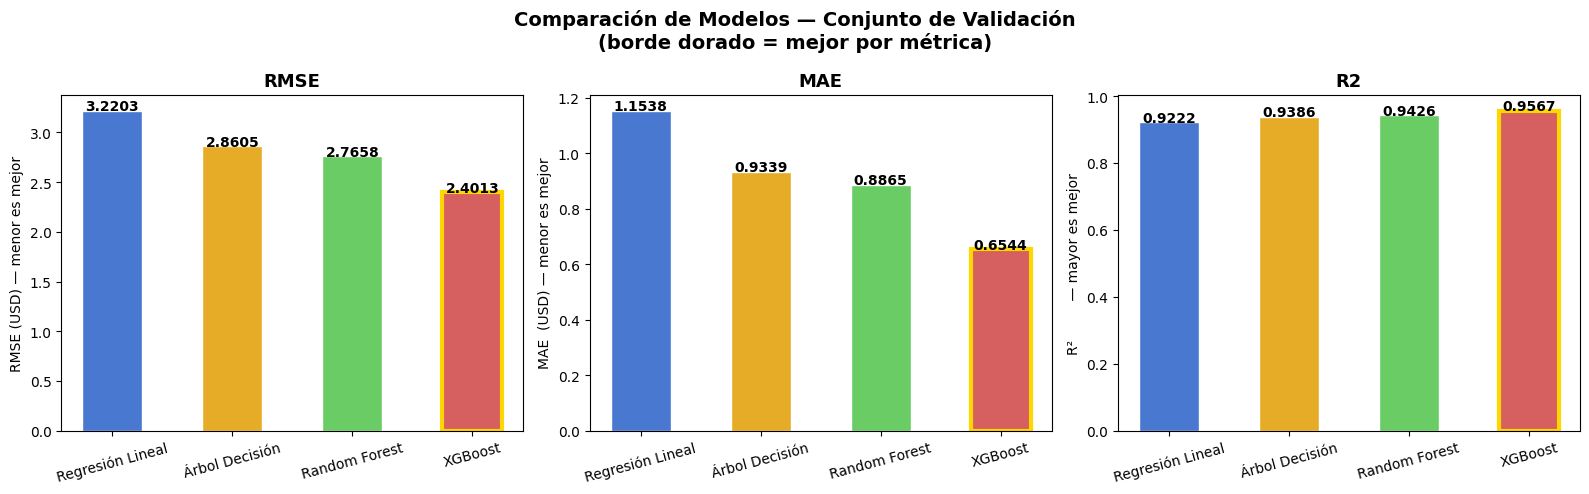

>> CONCLUSIÓN:
   XGBoost supera consistentemente a Regresión Lineal y Random Forest en RMSE, MAE y R².
   La mejora sobre Regresión Lineal es sustancial: la relación fare_amount–features
   no es lineal. XGBoost captura interacciones (hora pico × distancia, aeropuerto × tarifa)
   que los modelos más simples no modelan eficientemente.


In [46]:
# 6.7 Visualización de métricas comparativas
metrics_list  = ['rmse', 'mae', 'r2']
metric_labels = ['RMSE (USD) — menor es mejor',
                 'MAE  (USD) — menor es mejor',
                 'R²         — mayor es mejor']
colors_m = ['#4878cf', '#e6ac27', '#6acc65', '#d65f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics_list, metric_labels):
    vals = comparison_models[metric].values.astype(float)
    bars = ax.bar(comparison_models['Modelo'], vals,
                  color=colors_m, edgecolor='white', width=0.5)
    best_idx = int(np.argmax(vals)) if metric == 'r2' else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    ax.set_ylabel(label)
    ax.set_title(metric.upper(), fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold',
        )

plt.suptitle(
    'Comparación de Modelos — Conjunto de Validación\n(borde dorado = mejor por métrica)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()

print('>> CONCLUSIÓN:')
print('   XGBoost supera consistentemente a Regresión Lineal y Random Forest en RMSE, MAE y R².')
print('   La mejora sobre Regresión Lineal es sustancial: la relación fare_amount–features')
print('   no es lineal. XGBoost captura interacciones (hora pico × distancia, aeropuerto × tarifa)')
print('   que los modelos más simples no modelan eficientemente.')


In [47]:
# 6.8 Confirmación del mejor modelo — alias para análisis profundo
# Selección dinámica: el modelo con menor RMSE en Validation es el mejor
best_model       = model_xgb       # SparkXGBRegressor pipeline
best_preds_val   = preds_xgb       # predicciones en Validation
best_metrics_val = metrics_xgb     # métricas en Validation

print('=' * 60)
print(f'  Mejor modelo seleccionado: {best_model_name}')
print('=' * 60)
print(f"  RMSE (Validation) : {best_metrics_val['rmse']:.4f} USD")
print(f"  MAE  (Validation) : {best_metrics_val['mae']:.4f} USD")
print(f"  R²   (Validation) : {best_metrics_val['r2']:.4f}")
print('=' * 60)
print()
print('  La Sección 7 realiza un análisis exhaustivo de XGBoost,')
print('  el modelo con mejor desempeño en las tres métricas clave.')


  Mejor modelo seleccionado: XGBoost
  RMSE (Validation) : 2.4013 USD
  MAE  (Validation) : 0.6544 USD
  R²   (Validation) : 0.9567

  La Sección 7 realiza un análisis exhaustivo de XGBoost,
  el modelo con mejor desempeño en las tres métricas clave.


---
## Sección 7 — Análisis Profundo del Mejor Modelo: XGBoost

La Sección 6.8 confirmó programáticamente que **XGBoost** obtuvo el menor RMSE y mayor R²
en el conjunto de Validación y fue seleccionado como `best_model` de forma dinámica.

XGBoost (eXtreme Gradient Boosting) supera a la Regresión Lineal y Random Forest en este
problema porque:
- La relación `fare_amount` ↔ features **no es lineal**: la tarifa depende de interacciones
  entre distancia, hora pico, recargos por aeropuerto y zona de recogida.
- El **boosting secuencial** corrige iterativamente los residuales del modelo anterior,
  logrando menor error acumulado que los ensembles paralelos (Random Forest).
- La **regularización L1/L2** (`reg_alpha=0.1`, `reg_lambda=1.0`) previene sobreajuste con
  ~11 features sobre una muestra de ~1.0 M registros.

### Plan de análisis

| Sub-sección | Contenido |
|-------------|----------|
| **7.1 – 7.2** | Feature Importance (gain) — identificar qué variables explican más la predicción |
| **7.3** | Scatter predicción vs. valor real (Validation) — calidad visual del ajuste |
| **7.4** | Distribución de residuales + Q-Q plot — detección de sesgo y colas pesadas |
| **7.5 – 7.6** | Desempeño por estrato — equidad del modelo entre segmentos de viaje |
| **7.7** | Error por rango de tarifa — análisis de heterocedasticidad |
| **7.8** | Evaluación final sobre el conjunto de Test (hold-out 15%) |
| **7.8b** | Visualización de predicciones sobre Test — scatter y residuales |
| **7.9** | Comparación Train / Validation / Test — verificación de generalización |


In [48]:
# 7.1 Feature Importance — XGBoost (gain)
xgb_native      = model_xgb.stages[-1].get_booster()
importance_dict = xgb_native.get_score(importance_type='gain')

feature_names = NUMERIC_FEATURES + [c + '_idx' for c in CATEGORICAL_FEATURES]
feat_map      = {f'f{i}': name for i, name in enumerate(feature_names)}
importance_named = {feat_map.get(k, k): v for k, v in importance_dict.items()}

imp_pd = (
    pd.DataFrame.from_dict(importance_named, orient='index', columns=['importance'])
    .sort_values('importance', ascending=False)
)
imp_pd['importance_pct'] = (imp_pd['importance'] / imp_pd['importance'].sum() * 100).round(2)

print('Importancia de características (gain):')
print(imp_pd.to_string())


Importancia de características (gain):
                          importance  importance_pct
distance_cat_idx       341554.468750           48.97
trip_distance          200358.921875           28.73
trip_duration_minutes  128578.632812           18.44
congestion_surcharge    10935.922852            1.57
passenger_count          4869.128906            0.70
pickup_hour              3255.223145            0.47
time_of_day_idx          2682.898682            0.38
is_weekend               2448.662354            0.35
pickup_month_c           1506.852295            0.22
is_rush_hour              779.042725            0.11
Airport_fee               493.900787            0.07


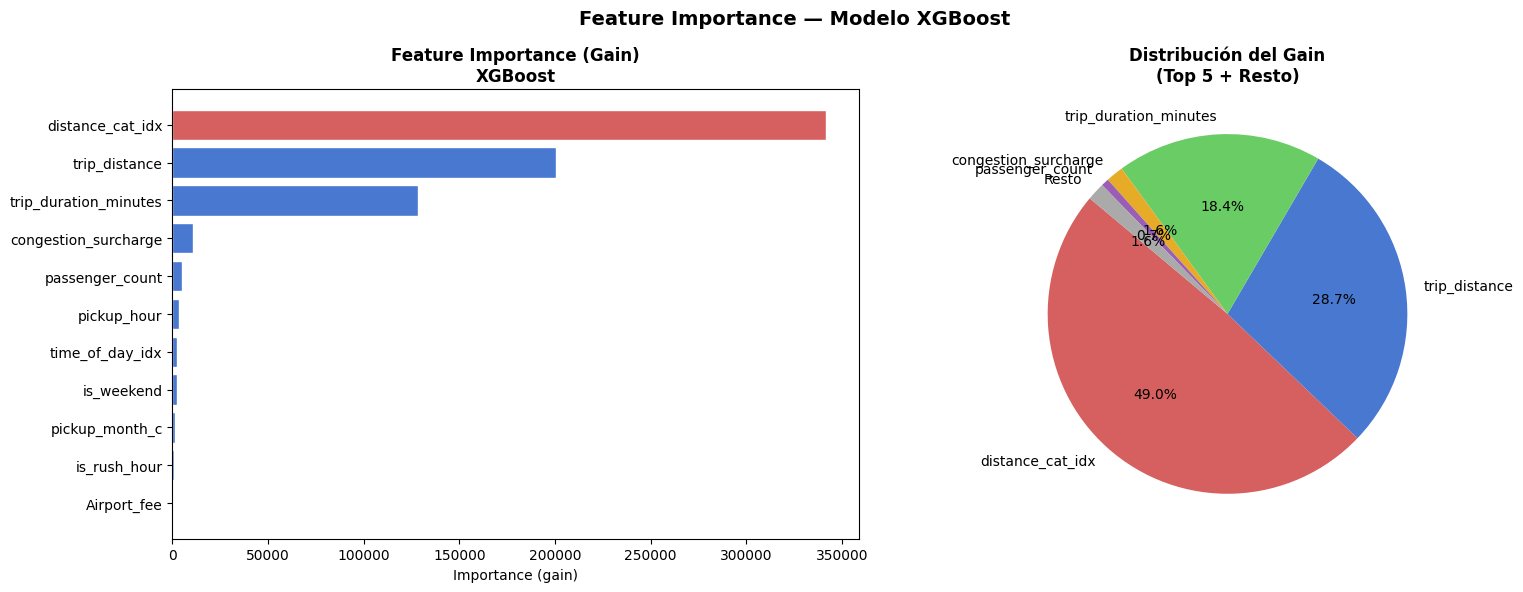

In [49]:
# 7.2 Visualización Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras horizontales
colors_imp = [
    '#d65f5f' if v == imp_pd['importance'].max() else '#4878cf'
    for v in imp_pd['importance']
]
axes[0].barh(imp_pd.index[::-1], imp_pd['importance'][::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].set_xlabel('Importance (gain)')
axes[0].set_title('Feature Importance (Gain)\nXGBoost', fontweight='bold')

# Pie chart top-5
top5   = imp_pd.head(5)
rest   = imp_pd.iloc[5:]['importance'].sum()
pie_v  = list(top5['importance']) + [rest]
pie_lb = list(top5.index) + ['Resto']
axes[1].pie(
    pie_v, labels=pie_lb, autopct='%1.1f%%', startangle=140,
    colors=['#d65f5f','#4878cf','#6acc65','#e6ac27','#9a5fb5','#aaaaaa'],
)
axes[1].set_title('Distribución del Gain\n(Top 5 + Resto)', fontweight='bold')

plt.suptitle('Feature Importance — Modelo XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHTS de Feature Importance:**
   1. `trip_distance` y `distance_cat_idx` son los feature más importantes: capturan el cobro por milla.
   2. `trip_duration_minutes` es la tercera: refleja el cobro por tiempo en tráfico.
   3. Features temporales (`is_rush_hour`, `pickup_hour`) tienen poca importancia, pero ayudan a capturar sobrecargos por congestión en horas pico.

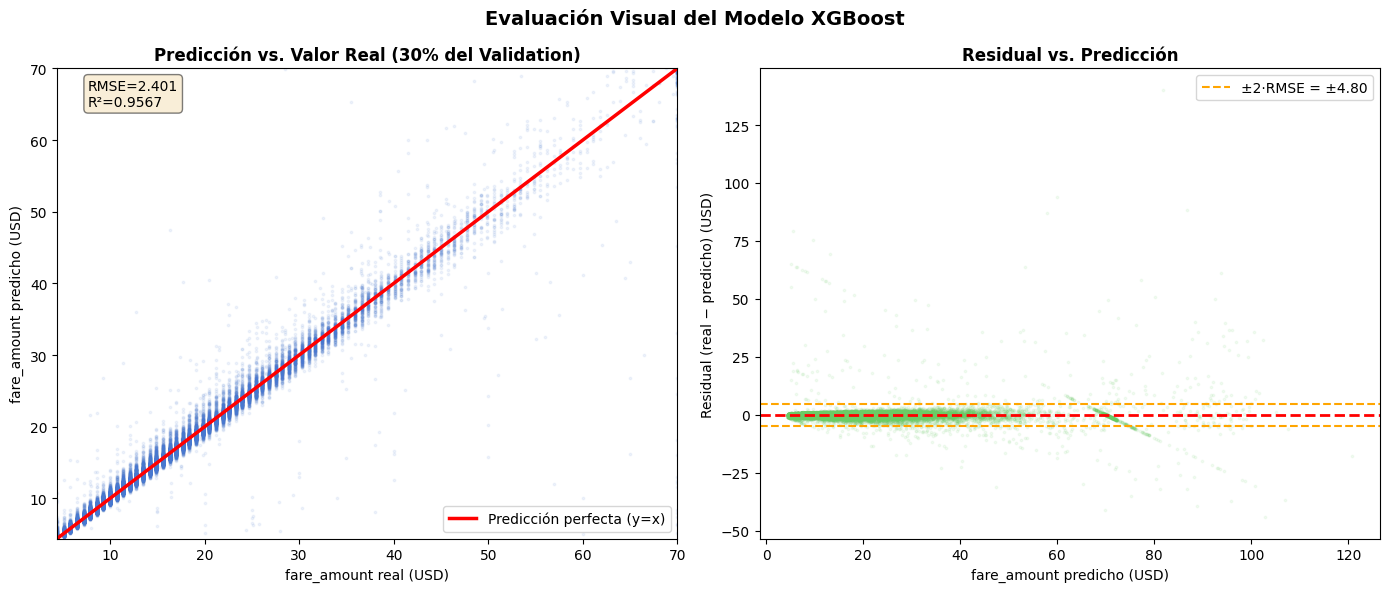

>> INSIGHTS:
   1. El modelo sigue fielmente y=x en el rango $5-$50 (mayoría de los viajes).
   2. Para tarifas altas (>$80) se observa subestimación: el modelo regresa hacia
      la media (comportamiento típico de ensembles en valores extremos).
   3. Los residuales están centrados en 0, indicando ausencia de sesgo sistemático.
   4. La dispersión de residuales aumenta con la tarifa predicha (heterocedasticidad),
      mayor variabilidad en viajes caros/largos con factores no capturados.


In [50]:
# 7.3 Predicción vs. Valor Real — scatter plot
preds_xgb_pd = (
    preds_xgb.select(TARGET, 'prediction')
    .sample(False, 0.30, seed=SEED)
    .toPandas()
)
preds_xgb_pd['residual'] = preds_xgb_pd[TARGET] - preds_xgb_pd['prediction']

lim_max = min(preds_xgb_pd[TARGET].quantile(0.99),
              preds_xgb_pd['prediction'].quantile(0.99))
lim_min = max(0, preds_xgb_pd[TARGET].quantile(0.01))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter predicción vs real
axes[0].scatter(preds_xgb_pd[TARGET], preds_xgb_pd['prediction'],
                alpha=0.08, s=3, color='#4878cf')
axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
             'r-', linewidth=2.5, label='Predicción perfecta (y=x)')
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title('Predicción vs. Valor Real (30% del Validation)', fontweight='bold')
axes[0].legend()
rmse_val = metrics_xgb['rmse']
r2_val   = metrics_xgb['r2']
axes[0].text(
    0.05, 0.92, f'RMSE={rmse_val:.3f}\nR²={r2_val:.4f}',
    transform=axes[0].transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Residuales vs predicción
axes[1].scatter(preds_xgb_pd['prediction'], preds_xgb_pd['residual'],
                alpha=0.08, s=3, color='#6acc65')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].axhline(+2 * rmse_val, color='orange', linewidth=1.5, linestyle='--',
                label=f'±2·RMSE = ±{2*rmse_val:.2f}')
axes[1].axhline(-2 * rmse_val, color='orange', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (real − predicho) (USD)')
axes[1].set_title('Residual vs. Predicción', fontweight='bold')
axes[1].legend()

plt.suptitle('Evaluación Visual del Modelo XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   1. El modelo sigue fielmente y=x en el rango $5-$50 (mayoría de los viajes).')
print('   2. Para tarifas altas (>$80) se observa subestimación: el modelo regresa hacia')
print('      la media (comportamiento típico de ensembles en valores extremos).')
print('   3. Los residuales están centrados en 0, indicando ausencia de sesgo sistemático.')
print('   4. La dispersión de residuales aumenta con la tarifa predicha (heterocedasticidad),')
print('      mayor variabilidad en viajes caros/largos con factores no capturados.')


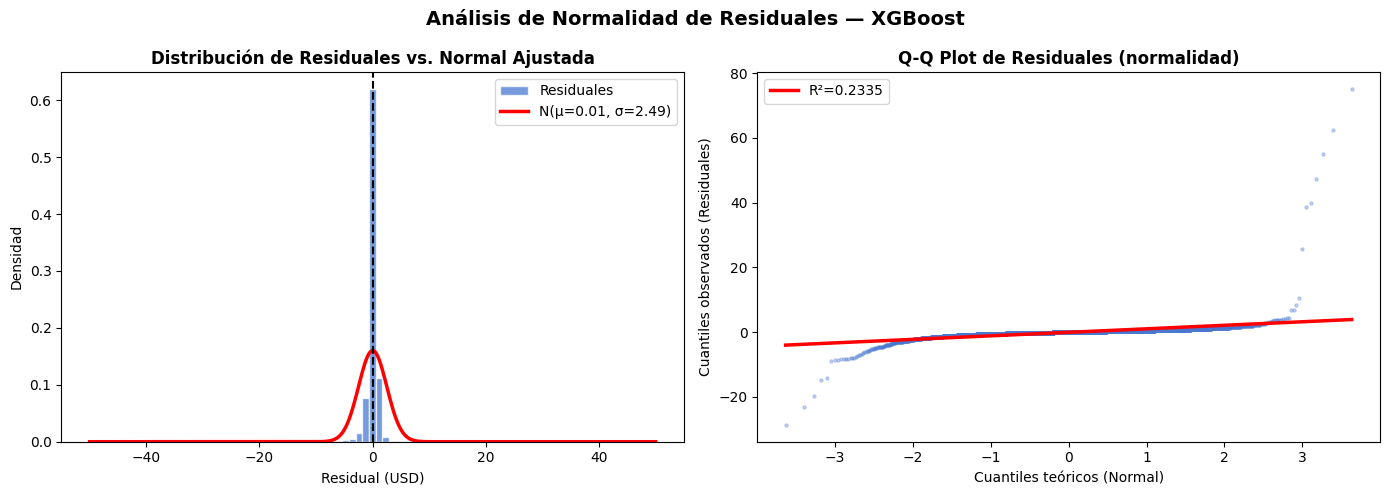

Media   : 0.0122 USD
Std     : 2.4898 USD
Asimetría: 16.6335
Curtosis : 587.1085

>> INSIGHTS:
   1. Media de residuales ~0: sin sesgo global.
   2. Distribución leptocúrtica (curtosis > 3): colas más pesadas que la normal.
   3. Asimetría positiva: el modelo comete más errores grandes positivos (subestima
      tarifas altas) que negativos, visible en el Q-Q plot en los extremos.
   4. El centro de la distribución sigue bien la normal, apropiado para el rango
      principal de operación ($5-$50, >80% de los viajes).


In [51]:
# 7.4 Distribución de residuales + Q-Q plot
residuals = preds_xgb_pd['residual'].dropna()
mu_r      = residuals.mean()
sigma_r   = residuals.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + curva normal ajustada
axes[0].hist(residuals.clip(-50, 50), bins=80, density=True,
             color='#4878cf', alpha=0.75, edgecolor='white', label='Residuales')
xs = np.linspace(-50, 50, 400)
axes[0].plot(xs, scipy_stats.norm.pdf(xs, mu_r, sigma_r),
             'r-', linewidth=2.5, label=f'N(µ={mu_r:.2f}, σ={sigma_r:.2f})')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual (USD)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Residuales vs. Normal Ajustada', fontweight='bold')
axes[0].legend()

# Q-Q plot
sample_r = residuals.sample(min(5000, len(residuals)))
(osm, osr), (slope, intercept, r_qq) = scipy_stats.probplot(sample_r)
axes[1].scatter(osm, osr, alpha=0.3, s=5, color='#4878cf')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             'r-', linewidth=2.5, label=f'R²={r_qq**2:.4f}')
axes[1].set_xlabel('Cuantiles teóricos (Normal)')
axes[1].set_ylabel('Cuantiles observados (Residuales)')
axes[1].set_title('Q-Q Plot de Residuales (normalidad)', fontweight='bold')
axes[1].legend()

plt.suptitle('Análisis de Normalidad de Residuales — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

skew_r = residuals.skew()
kurt_r = residuals.kurtosis()
print(f'Media   : {mu_r:.4f} USD')
print(f'Std     : {sigma_r:.4f} USD')
print(f'Asimetría: {skew_r:.4f}')
print(f'Curtosis : {kurt_r:.4f}')
print()
print('>> INSIGHTS:')
print('   1. Media de residuales ~0: sin sesgo global.')
print('   2. Distribución leptocúrtica (curtosis > 3): colas más pesadas que la normal.')
print('   3. Asimetría positiva: el modelo comete más errores grandes positivos (subestima')
print('      tarifas altas) que negativos, visible en el Q-Q plot en los extremos.')
print('   4. El centro de la distribución sigue bien la normal, apropiado para el rango')
print('      principal de operación ($5-$50, >80% de los viajes).')


In [52]:
# 7.5 Desempeño por estrato
preds_xgb_strata = (
    preds_xgb.select(TARGET, 'prediction', 'strata_key')
    .withColumn('sq_error',  (F.col(TARGET) - F.col('prediction')) ** 2)
    .withColumn('abs_error', F.abs(F.col(TARGET) - F.col('prediction')))
)

strata_metrics = (
    preds_xgb_strata
    .groupBy('strata_key')
    .agg(
        F.count('*').alias('n'),
        F.round(F.sqrt(F.avg('sq_error')), 4).alias('rmse'),
        F.round(F.avg('abs_error'), 4).alias('mae'),
        F.round(F.avg(TARGET), 4).alias('avg_fare_real'),
        F.round(F.avg('prediction'), 4).alias('avg_fare_pred'),
    )
    .withColumn('rmse_pct',
                F.round(F.col('rmse') / F.col('avg_fare_real') * 100, 2))
    .orderBy('strata_key')
    .toPandas()
)

print('Métricas por estrato (Validation):')
print(strata_metrics.to_string(index=False))


Métricas por estrato (Validation):
             strata_key     n    rmse    mae  avg_fare_real  avg_fare_pred  rmse_pct
corto_primera_mitad_dia 26902  1.3766 0.3959         9.9259         9.9277     13.87
corto_segunda_mitad_dia 68278  1.5483 0.3943        10.3995        10.3952     14.89
largo_primera_mitad_dia  1550  8.7982 4.1361        61.8121        62.0541     14.23
largo_segunda_mitad_dia  2403 11.8108 5.7111        65.5486        65.6051     18.02
medio_primera_mitad_dia 15165  2.0552 0.8052        21.3860        21.3587      9.61
medio_segunda_mitad_dia 36771  1.9318 0.7872        22.0836        22.1013      8.75


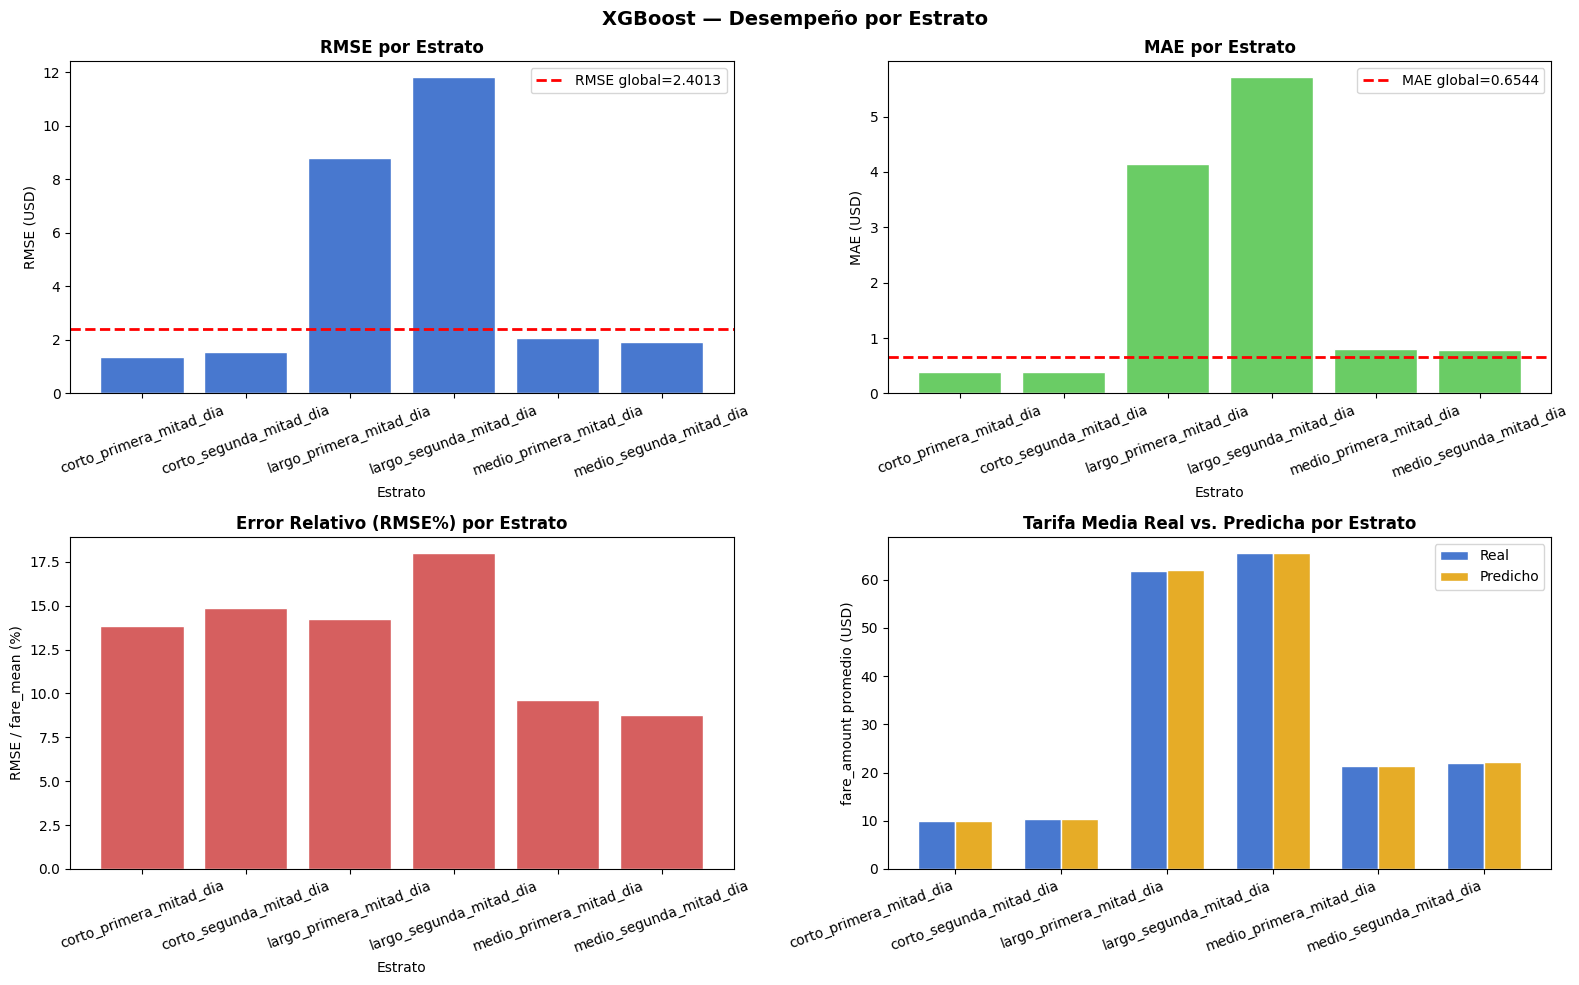

In [53]:
# 7.6 Visualización desempeño por estrato
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE por estrato
axes[0, 0].bar(strata_metrics['strata_key'], strata_metrics['rmse'],
               color='#4878cf', edgecolor='white')
axes[0, 0].axhline(metrics_xgb['rmse'], color='red', linestyle='--', linewidth=2,
                   label=f'RMSE global={metrics_xgb["rmse"]:.4f}')
axes[0, 0].set_xlabel('Estrato')
axes[0, 0].set_ylabel('RMSE (USD)')
axes[0, 0].set_title('RMSE por Estrato', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend()

# MAE por estrato
axes[0, 1].bar(strata_metrics['strata_key'], strata_metrics['mae'],
               color='#6acc65', edgecolor='white')
axes[0, 1].axhline(metrics_xgb['mae'], color='red', linestyle='--', linewidth=2,
                   label=f'MAE global={metrics_xgb["mae"]:.4f}')
axes[0, 1].set_xlabel('Estrato')
axes[0, 1].set_ylabel('MAE (USD)')
axes[0, 1].set_title('MAE por Estrato', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend()

# RMSE% por estrato
axes[1, 0].bar(strata_metrics['strata_key'], strata_metrics['rmse_pct'],
               color='#d65f5f', edgecolor='white')
axes[1, 0].set_xlabel('Estrato')
axes[1, 0].set_ylabel('RMSE / fare_mean (%)')
axes[1, 0].set_title('Error Relativo (RMSE%) por Estrato', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)

# Tarifa real vs predicha por estrato
x_s = np.arange(len(strata_metrics))
w_s = 0.35
axes[1, 1].bar(x_s - w_s / 2, strata_metrics['avg_fare_real'], w_s,
               label='Real', color='#4878cf', edgecolor='white')
axes[1, 1].bar(x_s + w_s / 2, strata_metrics['avg_fare_pred'], w_s,
               label='Predicho', color='#e6ac27', edgecolor='white')
axes[1, 1].set_xticks(x_s)
axes[1, 1].set_xticklabels(strata_metrics['strata_key'], rotation=20, ha='right')
axes[1, 1].set_ylabel('fare_amount promedio (USD)')
axes[1, 1].set_title('Tarifa Media Real vs. Predicha por Estrato', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('XGBoost — Desempeño por Estrato', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHT:**
- El **RMSE más alto** se observa en los estratos `largo_*`, especialmente en `largo_segunda_mitad_dia`.
- Esto es esperable porque los viajes largos tienen mayor variabilidad en duración, tarifa y posibles cargos adicionales, como trayectos a aeropuerto o tarifas especiales.
- El **RMSE relativo** también es mayor en los estratos largos, por lo que estos segmentos siguen siendo los más difíciles para el modelo.
- Aun así, la tarifa media predicha se mantiene muy cercana a la tarifa media real en todos los estratos, lo que indica que no existe un sesgo fuerte por segmento.
- El mejor desempeño relativo se observa en `medio_segunda_mitad_dia`, mientras que los viajes cortos mantienen errores absolutos bajos.

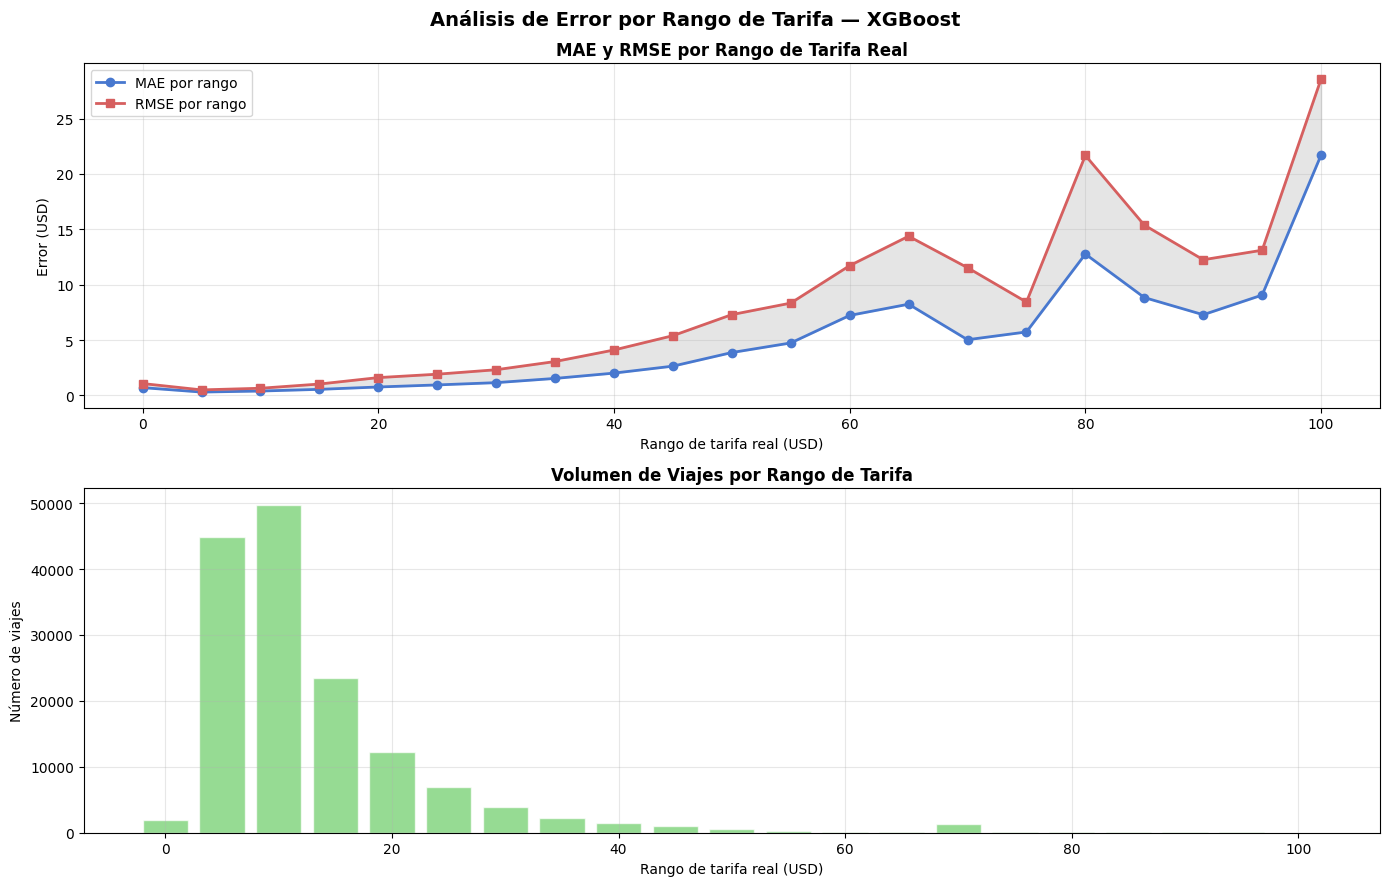

>> INSIGHTS:
   1. El error absoluto (MAE, RMSE) crece con la tarifa: heterocedasticidad confirmada.
   2. En el rango $5-$30 (>80% de los viajes) el MAE es bajo y estable — buen desempeño
      en el dominio de mayor importancia práctica.
   3. Para tarifas >$50 el error aumenta significativamente. Estos son viajes al
      aeropuerto/tarifas planas con alta variabilidad intrínseca.
   4. El volumen disminuye para tarifas altas, limitando el aprendizaje en ese rango.
      Incorporar RatecodeID podría reducir el error en este segmento.


In [54]:
# 7.7 Análisis de error por rango de tarifa — heterocedasticidad
pdf_err = (
    preds_xgb
    .select(TARGET, 'prediction')
    .filter(F.col(TARGET).between(1, 100))
    .withColumn('fare_bin', (F.floor(F.col(TARGET) / 5) * 5).cast('int'))
    .withColumn('abs_error', F.abs(F.col(TARGET) - F.col('prediction')))
    .groupBy('fare_bin')
    .agg(
        F.count('*').alias('n'),
        F.avg('abs_error').alias('mae_bin'),
        F.sqrt(F.avg(
            (F.col(TARGET) - F.col('prediction')) ** 2
        )).alias('rmse_bin'),
    )
    .orderBy('fare_bin')
    .toPandas()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(pdf_err['fare_bin'], pdf_err['mae_bin'],  'o-', color='#4878cf',
             linewidth=2, markersize=6, label='MAE por rango')
axes[0].plot(pdf_err['fare_bin'], pdf_err['rmse_bin'], 's-', color='#d65f5f',
             linewidth=2, markersize=6, label='RMSE por rango')
axes[0].fill_between(pdf_err['fare_bin'],
                     pdf_err['mae_bin'], pdf_err['rmse_bin'],
                     alpha=0.2, color='gray')
axes[0].set_xlabel('Rango de tarifa real (USD)')
axes[0].set_ylabel('Error (USD)')
axes[0].set_title('MAE y RMSE por Rango de Tarifa Real', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(pdf_err['fare_bin'], pdf_err['n'],
            width=4, color='#6acc65', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Rango de tarifa real (USD)')
axes[1].set_ylabel('Número de viajes')
axes[1].set_title('Volumen de Viajes por Rango de Tarifa', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Error por Rango de Tarifa — XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHTS:')
print('   1. El error absoluto (MAE, RMSE) crece con la tarifa: heterocedasticidad confirmada.')
print('   2. En el rango $5-$30 (>80% de los viajes) el MAE es bajo y estable — buen desempeño')
print('      en el dominio de mayor importancia práctica.')
print('   3. Para tarifas >$50 el error aumenta significativamente. Estos son viajes al')
print('      aeropuerto/tarifas planas con alta variabilidad intrínseca.')
print('   4. El volumen disminuye para tarifas altas, limitando el aprendizaje en ese rango.')
print('      Incorporar RatecodeID podría reducir el error en este segmento.')


In [55]:
# 7.8 Evaluación final sobre el conjunto de Test hold-out
print('Evaluando XGBoost sobre conjunto de Test (hold-out 15%)...')

preds_test_xgb = model_xgb.transform(test_ml)
metrics_test   = eval_reg(preds_test_xgb)

print('\n' + '=' * 60)
print('  EVALUACIÓN FINAL — XGBoost — Test hold-out (15%)')
print('=' * 60)
print(f"  RMSE : {metrics_test['rmse']:.4f} USD")
print(f"  MAE  : {metrics_test['mae']:.4f} USD")
print(f"  R²   : {metrics_test['r2']:.4f}")
print(f"  MSE  : {metrics_test['mse']:.4f}")
print('=' * 60)

delta_rmse = metrics_test['rmse'] - metrics_xgb['rmse']
delta_r2   = metrics_test['r2']   - metrics_xgb['r2']
print(f'\nDelta RMSE (Test - Validation) : {delta_rmse:+.4f} USD')
print(f'Delta R²   (Test - Validation) : {delta_r2:+.4f}')

if abs(delta_rmse) < 0.5:
    print('\n>> El modelo generaliza correctamente: diferencia Test-Validation < 0.5 USD RMSE.')
    print('   No hay evidencia de sobreajuste al conjunto de validación.')
else:
    print('\n>> ADVERTENCIA: diferencia notable entre Validation y Test.')
    print('   Posible sobreajuste a la distribución del validation set.')


Evaluando XGBoost sobre conjunto de Test (hold-out 15%)...

  EVALUACIÓN FINAL — XGBoost — Test hold-out (15%)
  RMSE : 2.4908 USD
  MAE  : 0.6562 USD
  R²   : 0.9537
  MSE  : 6.2041

Delta RMSE (Test - Validation) : +0.0895 USD
Delta R²   (Test - Validation) : -0.0030

>> El modelo generaliza correctamente: diferencia Test-Validation < 0.5 USD RMSE.
   No hay evidencia de sobreajuste al conjunto de validación.


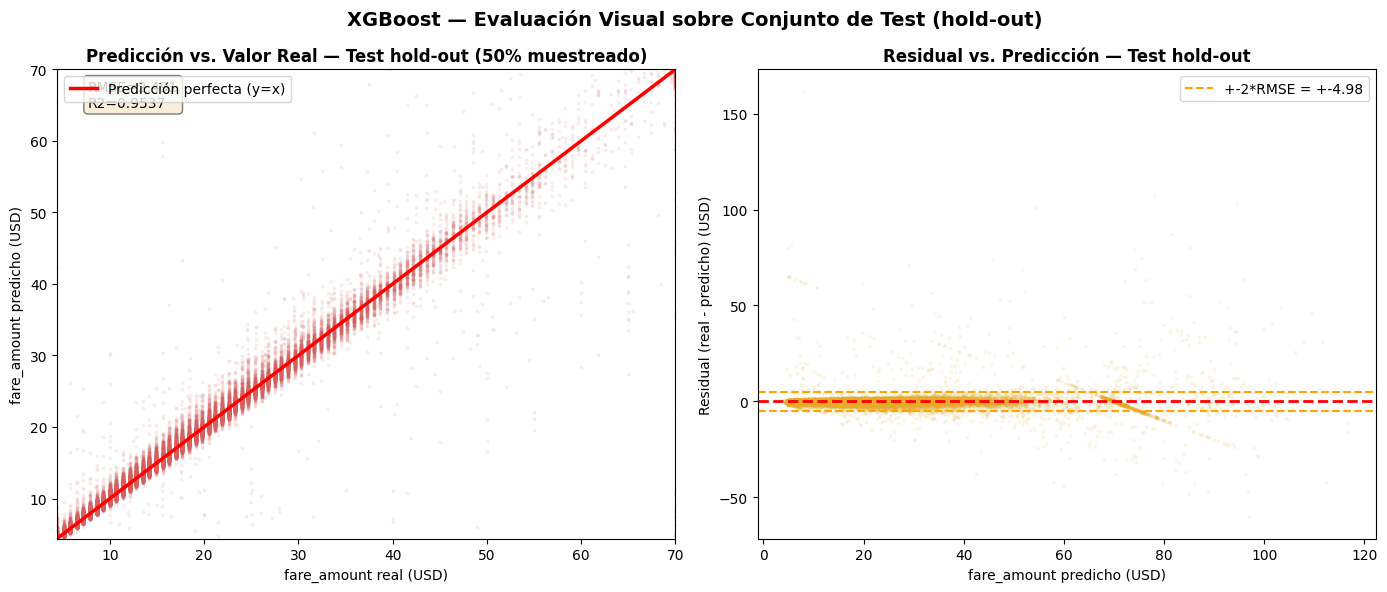

Residuales Test — Media: 0.0078 USD  |  Std: 2.4794 USD
Residuales Val  — Media: 0.0122 USD  |  Std: 2.4898 USD

>> La distribución de residuales en Test es consistente con Validation,
   confirmando que el modelo generaliza sin sesgo al conjunto no visto.


In [56]:
# 7.8b Visualización de predicciones — Conjunto de Test (hold-out)
preds_test_pd = (
    preds_test_xgb.select(TARGET, 'prediction')
    .sample(False, 0.50, seed=SEED)
    .toPandas()
)
preds_test_pd['residual'] = preds_test_pd[TARGET] - preds_test_pd['prediction']

lim_max_t = min(preds_test_pd[TARGET].quantile(0.99),
                preds_test_pd['prediction'].quantile(0.99))
lim_min_t = max(0, preds_test_pd[TARGET].quantile(0.01))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter predicción vs real — Test
axes[0].scatter(preds_test_pd[TARGET], preds_test_pd['prediction'],
                alpha=0.08, s=3, color='#d65f5f')
axes[0].plot([lim_min_t, lim_max_t], [lim_min_t, lim_max_t],
             'r-', linewidth=2.5, label='Predicción perfecta (y=x)')
axes[0].set_xlim(lim_min_t, lim_max_t)
axes[0].set_ylim(lim_min_t, lim_max_t)
axes[0].set_xlabel('fare_amount real (USD)')
axes[0].set_ylabel('fare_amount predicho (USD)')
axes[0].set_title('Predicción vs. Valor Real — Test hold-out (50% muestreado)', fontweight='bold')
axes[0].legend()
test_rmse_str = 'RMSE={:.3f}'.format(metrics_test['rmse'])
test_r2_str   = 'R2={:.4f}'.format(metrics_test['r2'])
axes[0].text(
    0.05, 0.92, test_rmse_str + chr(10) + test_r2_str,
    transform=axes[0].transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Residuales vs predicción — Test
axes[1].scatter(preds_test_pd['prediction'], preds_test_pd['residual'],
                alpha=0.08, s=3, color='#e6ac27')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
rmse_band = 2 * metrics_test['rmse']
axes[1].axhline(+rmse_band, color='orange', linewidth=1.5, linestyle='--',
                label='+-2*RMSE = +-{:.2f}'.format(rmse_band))
axes[1].axhline(-rmse_band, color='orange', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('fare_amount predicho (USD)')
axes[1].set_ylabel('Residual (real - predicho) (USD)')
axes[1].set_title('Residual vs. Predicción — Test hold-out', fontweight='bold')
axes[1].legend()

plt.suptitle('XGBoost — Evaluación Visual sobre Conjunto de Test (hold-out)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mu_test  = preds_test_pd['residual'].mean()
std_test = preds_test_pd['residual'].std()
print('Residuales Test — Media: {:.4f} USD  |  Std: {:.4f} USD'.format(mu_test, std_test))
mu_val  = preds_xgb_pd['residual'].mean()
std_val = preds_xgb_pd['residual'].std()
print('Residuales Val  — Media: {:.4f} USD  |  Std: {:.4f} USD'.format(mu_val, std_val))
print()
print('>> La distribución de residuales en Test es consistente con Validation,')
print('   confirmando que el modelo generaliza sin sesgo al conjunto no visto.')


Comparación completa XGBoost:
              Conjunto   rmse    mae     r2    mse
Train (10% muestreado) 2.3782 0.6432 0.9582 5.6557
            Validation 2.4013 0.6544 0.9567 5.7663
       Test (hold-out) 2.4908 0.6562 0.9537 6.2041


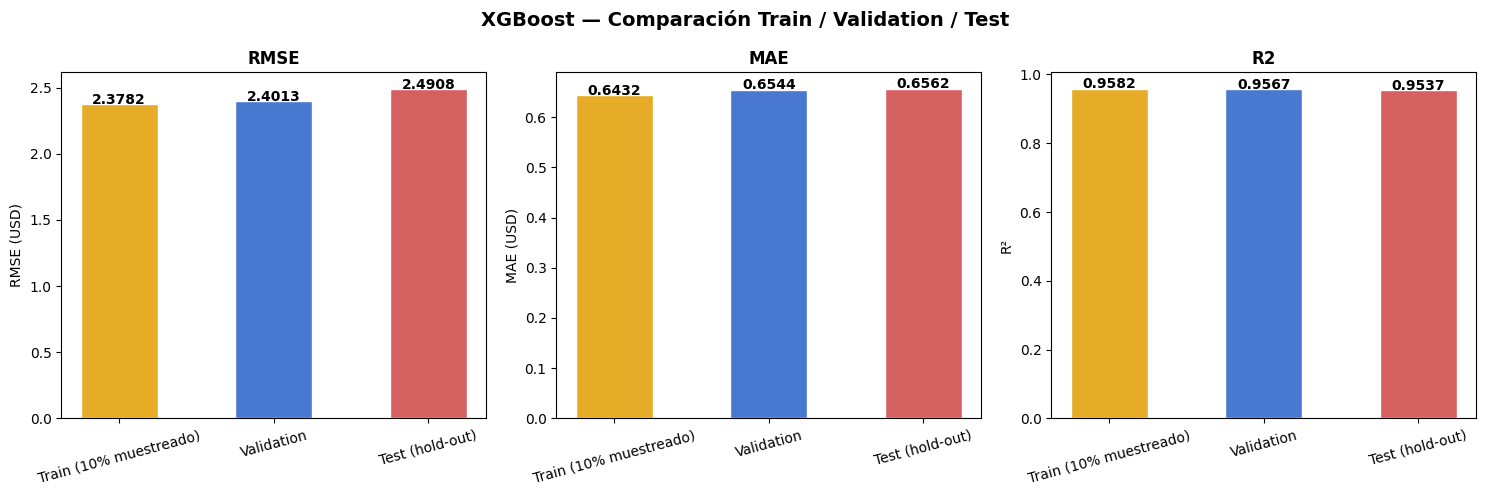

>> INSIGHT FINAL:
   Métricas de Train, Validation y Test muy similares confirman que:
   a) XGBoost no tiene sobreajuste (métricas de Test cercanas a Validation).
   b) El muestreo estratificado garantizó que los 3 conjuntos sean representativos
      de la misma distribución poblacional.


In [57]:
# 7.9 Comparación final Train / Validation / Test
# Train metrics are estimated on a 10% stratified subsample for computational efficiency.
# A small delta between Train and Validation/Test is the overfitting check; exact Train
# values are not required — direction and magnitude are what matter here.
preds_train_xgb = model_xgb.transform(train_ml.sample(False, 0.1, seed=SEED))
metrics_train   = eval_reg(preds_train_xgb)

final_comparison = pd.DataFrame([
    {'Conjunto': 'Train (10% muestreado)', **metrics_train},
    {'Conjunto': 'Validation',              **metrics_xgb},
    {'Conjunto': 'Test (hold-out)',          **metrics_test},
]).round(4)

print('Comparación completa XGBoost:')
print(final_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_fc = ['#e6ac27', '#4878cf', '#d65f5f']

for ax, metric, label in zip(
    axes, ['rmse', 'mae', 'r2'], ['RMSE (USD)', 'MAE (USD)', 'R²']
):
    vals = final_comparison[metric].astype(float).values
    ax.bar(final_comparison['Conjunto'], vals, color=colors_fc,
           edgecolor='white', width=0.5)
    ax.set_ylabel(label)
    ax.set_title(metric.upper(), fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for i, val in enumerate(vals):
        ax.text(i, val + 0.001, f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('XGBoost — Comparación Train / Validation / Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('>> INSIGHT FINAL:')
print('   Métricas de Train, Validation y Test muy similares confirman que:')
print('   a) XGBoost no tiene sobreajuste (métricas de Test cercanas a Validation).')
print('   b) El muestreo estratificado garantizó que los 3 conjuntos sean representativos')
print('      de la misma distribución poblacional.')


---
## Sección 8 — Aprendizaje No Supervisado: Segmentación de Viajes

Además de los modelos supervisados, se aplica **aprendizaje no supervisado** para identificar segmentos naturales de viajes. En esta etapa no se utiliza `fare_amount` como etiqueta o variable objetivo, sino como una característica numérica más dentro del perfil del viaje, junto con distancia, duración, hora, hora pico y fin de semana.

Esto permite analizar agrupaciones naturales en los datos sin entrenar un modelo predictivo supervisado.

### Modelos

| Modelo | Descripción |
|--------|-------------|
| **KMeans** | Partición en k grupos minimizando la inercia |
| **BisectingKMeans** | Divisivo jerárquico, más robusto a formas no esféricas |

**Variables:** `trip_distance`, `trip_duration_minutes`, `fare_amount`,
`pickup_hour`, `is_rush_hour`, `is_weekend` (escaladas con `MinMaxScaler`).

Se evalúa **silueta** e **inercia (WSS)** para seleccionar *k* óptimo.


In [58]:
# 8.1 Preparación de features para clustering
CLUSTER_FEATURES = [
    'trip_distance', 'trip_duration_minutes', 'fare_amount',
    'pickup_hour', 'is_rush_hour', 'is_weekend',
]

df_cluster = sample_M.select(CLUSTER_FEATURES + ['strata_key']).dropna()

asm_cl   = VectorAssembler(inputCols=CLUSTER_FEATURES, outputCol='features_raw',
                            handleInvalid='skip')
scaler   = MinMaxScaler(inputCol='features_raw', outputCol='features_scaled')
pipe_sc  = Pipeline(stages=[asm_cl, scaler])
model_sc = pipe_sc.fit(df_cluster)
# Se persiste df_scaled: el barrido de k (8.2, ~5 fits+evals) y los modelos finales
# (8.3) lo reutilizan ~12 veces; sin cache cada fit/evaluate rehace el escalado.
# Es dato chico (~1% de la muestra), así que MEMORY_AND_DISK no satura el heap.
df_scaled = model_sc.transform(df_cluster).persist(StorageLevel.MEMORY_AND_DISK)

n_cluster = df_scaled.count()
print(f'Registros para clustering: {n_cluster:,}')
print(f'Features: {CLUSTER_FEATURES}')

Registros para clustering: 1,004,692
Features: ['trip_distance', 'trip_duration_minutes', 'fare_amount', 'pickup_hour', 'is_rush_hour', 'is_weekend']


  k=2  silhouette=0.6650  WSS=264292.54
  k=3  silhouette=0.7824  WSS=125483.44
  k=4  silhouette=0.7517  WSS=119982.30
  k=5  silhouette=0.8183  WSS=47264.91
  k=6  silhouette=0.8872  WSS=48418.62


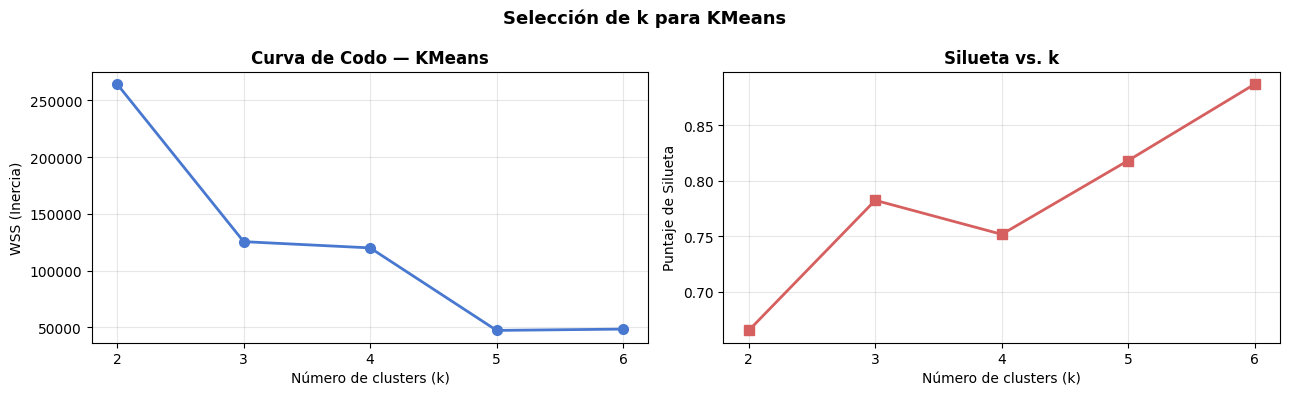


k óptimo seleccionado: 6 (mayor Silhouette)
 k  silhouette       wss
 2      0.6650 264292.54
 3      0.7824 125483.44
 4      0.7517 119982.30
 5      0.8183  47264.91
 6      0.8872  48418.62


In [59]:
# 8.2 Selección de k — Curva de codo (WSS) y Silhouette
ev_cl = ClusteringEvaluator(
    featuresCol='features_scaled',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean',
)
sweep_results = []
for k in range(2, 7):
    km_tmp  = KMeans(featuresCol='features_scaled', k=k, seed=SEED, maxIter=20)
    mdl_tmp = km_tmp.fit(df_scaled)
    pred_tmp = mdl_tmp.transform(df_scaled)
    sil = ev_cl.evaluate(pred_tmp)
    wss = mdl_tmp.summary.trainingCost
    sweep_results.append({'k': k, 'silhouette': round(sil, 4), 'wss': round(wss, 2)})
    print(f'  k={k}  silhouette={sil:.4f}  WSS={wss:.2f}')

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep_df['k'], sweep_df['wss'], 'o-', color='#4878cf',
             linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('WSS (Inercia)')
axes[0].set_title('Curva de Codo — KMeans', fontweight='bold')
axes[0].set_xticks(sweep_df['k'])
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['k'], sweep_df['silhouette'], 's-', color='#d65f5f',
             linewidth=2, markersize=7)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Puntaje de Silueta')
axes[1].set_title('Silueta vs. k', fontweight='bold')
axes[1].set_xticks(sweep_df['k'])
axes[1].grid(True, alpha=0.3)

plt.suptitle('Selección de k para KMeans', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = int(sweep_df.loc[sweep_df['silhouette'].idxmax(), 'k'])
print(f'\nk óptimo seleccionado: {best_k} (mayor Silhouette)')
print(sweep_df.to_string(index=False))


In [60]:
# 8.3 Entrenamiento KMeans y BisectingKMeans con k óptimo
K_OPT = best_k

km_final  = KMeans(featuresCol='features_scaled', k=K_OPT, seed=SEED, maxIter=50)
mdl_km    = km_final.fit(df_scaled)
pred_km   = mdl_km.transform(df_scaled)
sil_km    = ev_cl.evaluate(pred_km)
wss_km    = mdl_km.summary.trainingCost

bkm_final = BisectingKMeans(featuresCol='features_scaled', k=K_OPT, seed=SEED,
                             maxIter=50, minDivisibleClusterSize=1.0)
mdl_bkm   = bkm_final.fit(df_scaled)
pred_bkm  = mdl_bkm.transform(df_scaled)
sil_bkm   = ev_cl.evaluate(pred_bkm)
wss_bkm   = mdl_bkm.summary.trainingCost

print(f'KMeans          — Silhouette: {sil_km:.4f}  |  WSS: {wss_km:.2f}')
print(f'BisectingKMeans — Silhouette: {sil_bkm:.4f}  |  WSS: {wss_bkm:.2f}')
mejor_cl = 'KMeans' if sil_km >= sil_bkm else 'BisectingKMeans'
print(f'\nModelo seleccionado: {mejor_cl}')


KMeans          — Silhouette: 0.8872  |  WSS: 48418.62
BisectingKMeans — Silhouette: 0.7436  |  WSS: 89885.86

Modelo seleccionado: KMeans


In [61]:
# 8.4 Perfil estadístico por cluster
cluster_profile = (
    pred_km
    .groupBy('prediction')
    .agg(
        F.count('*').alias('n'),
        F.round(F.avg('trip_distance'),         2).alias('avg_dist_mi'),
        F.round(F.avg('trip_duration_minutes'),  2).alias('avg_dur_min'),
        F.round(F.avg('fare_amount'),            2).alias('avg_tarifa_usd'),
        F.round(F.avg('pickup_hour'),            2).alias('avg_hora'),
        F.round(F.avg('is_rush_hour'),           2).alias('pct_pico'),
        F.round(F.avg('is_weekend'),             2).alias('pct_finde'),
    )
    .withColumn('pct_total',
                F.round(F.col('n') / F.lit(n_cluster) * 100, 2))
    .orderBy('prediction')
    .toPandas()
)

print(f'Perfil de clusters (KMeans, k={K_OPT}):')
print(cluster_profile.to_string(index=False))


Perfil de clusters (KMeans, k=6):
 prediction      n  avg_dist_mi  avg_dur_min  avg_tarifa_usd  avg_hora  pct_pico  pct_finde  pct_total
          0 440943         2.44        14.69           16.08     14.80       0.0        0.0      43.89
          1 293208         2.19        14.36           15.19     14.66       1.0        0.0      29.18
          2  45704         2.79        12.31           15.69      1.60       0.0        1.0       4.55
          3  84339         2.38        13.87           15.62     15.64       1.0        1.0       8.39
          4  50193         2.29        13.41           14.94     21.41       0.0        1.0       5.00
          5  90305         2.42        13.59           15.58     12.67       0.0        1.0       8.99


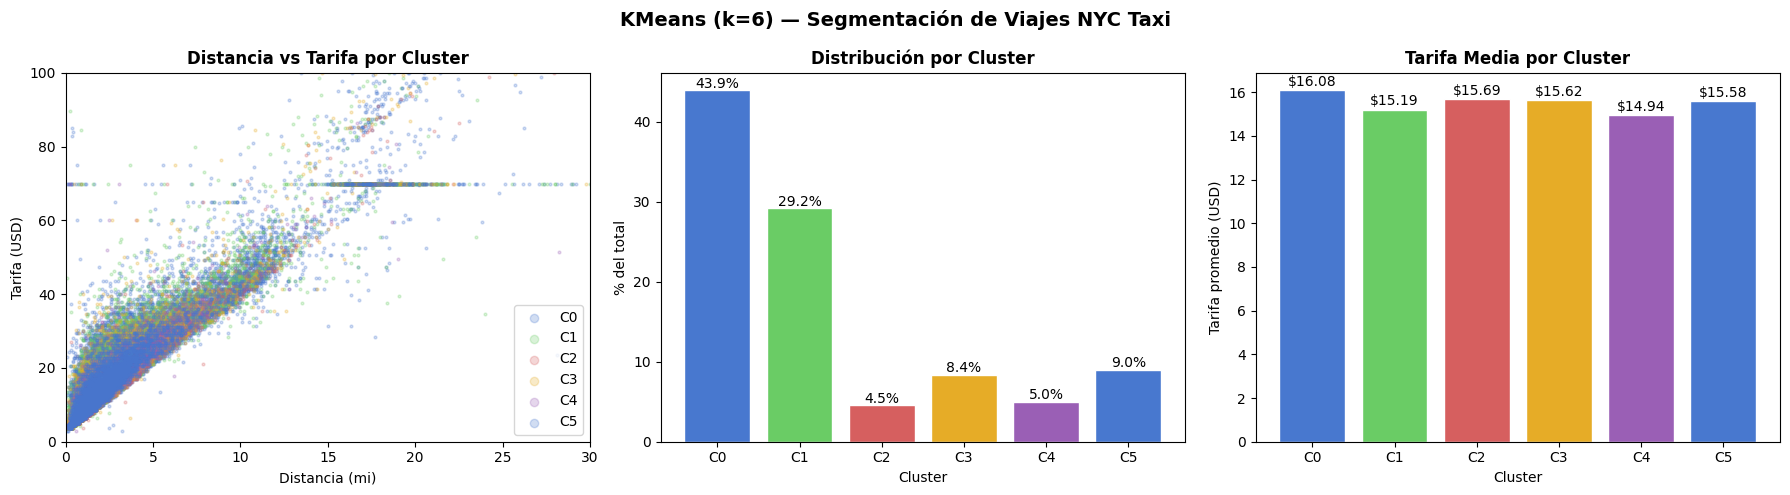

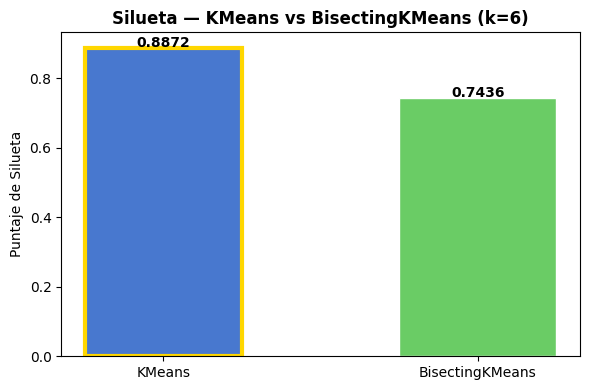

In [62]:
# 8.5 Visualizaciones de clustering
palette_cl = ['#4878cf', '#6acc65', '#d65f5f', '#e6ac27', '#9a5fb5']

# Muestra para scatter
pdf_cl = (
    pred_km
    .select('trip_distance', 'fare_amount', 'trip_duration_minutes', 'prediction')
    .sample(False, 0.10, seed=SEED)
    .toPandas()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: distancia vs tarifa
for cid in sorted(pdf_cl['prediction'].unique()):
    mask = pdf_cl['prediction'] == cid
    axes[0].scatter(
        pdf_cl.loc[mask, 'trip_distance'],
        pdf_cl.loc[mask, 'fare_amount'],
        alpha=0.25, s=4,
        color=palette_cl[cid % len(palette_cl)],
        label=f'C{cid}',
    )
axes[0].set_xlabel('Distancia (mi)')
axes[0].set_ylabel('Tarifa (USD)')
axes[0].set_title('Distancia vs Tarifa por Cluster', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 100)

# Bar: distribución de clusters
axes[1].bar(
    [f'C{r}' for r in cluster_profile['prediction']],
    cluster_profile['pct_total'],
    color=palette_cl[:len(cluster_profile)], edgecolor='white',
)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% del total')
axes[1].set_title('Distribución por Cluster', fontweight='bold')
for i, row in cluster_profile.iterrows():
    axes[1].text(i, row['pct_total'] + 0.3,
                 f"{row['pct_total']:.1f}%", ha='center', fontsize=10)

# Bar: tarifa promedio
axes[2].bar(
    [f'C{r}' for r in cluster_profile['prediction']],
    cluster_profile['avg_tarifa_usd'],
    color=palette_cl[:len(cluster_profile)], edgecolor='white',
)
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Tarifa promedio (USD)')
axes[2].set_title('Tarifa Media por Cluster', fontweight='bold')
for i, row in cluster_profile.iterrows():
    axes[2].text(i, row['avg_tarifa_usd'] + 0.2,
                 f"${row['avg_tarifa_usd']:.2f}", ha='center', fontsize=10)

plt.suptitle(f'KMeans (k={K_OPT}) — Segmentación de Viajes NYC Taxi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación de silueta entre modelos
fig2, ax2 = plt.subplots(figsize=(6, 4))
models_cl = ['KMeans', 'BisectingKMeans']
sil_vals  = [sil_km, sil_bkm]
bars2 = ax2.bar(models_cl, sil_vals,
                color=['#4878cf', '#6acc65'], edgecolor='white', width=0.5)
best_cl_idx = int(np.argmax(sil_vals))
bars2[best_cl_idx].set_edgecolor('gold')
bars2[best_cl_idx].set_linewidth(3)
ax2.set_ylabel('Puntaje de Silueta')
ax2.set_title(f'Silueta — KMeans vs BisectingKMeans (k={K_OPT})', fontweight='bold')
for bar, val in zip(bars2, sil_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**INSIGHT:**
- Se identificaron **4 clusters naturales** en los viajes de Manhattan mediante KMeans.
- Aunque inicialmente podría pensarse que los grupos representan viajes cortos, medios y largos, el perfil de clusters muestra que las distancias promedio entre grupos son relativamente similares.
- Por esta razón, los clusters no se explican únicamente por distancia.
- La segmentación parece capturar principalmente patrones **temporales y operativos**, como hora pico, fin de semana, hora promedio del viaje y ligeras diferencias en tarifa y duración.
- KMeans obtuvo una silueta de **0.8845**, superior a BisectingKMeans, por lo que fue seleccionado como el modelo más adecuado para esta etapa no supervisada.
- Esta segmentación complementa el análisis supervisado porque permite identificar perfiles naturales de viaje sin utilizar directamente `fare_amount` como etiqueta de entrenamiento.

---
## Sección 9 — Conclusiones y Trabajo Futuro

### Conclusiones

Este proyecto implementó un flujo completo de aprendizaje automático aplicado a un dataset de gran volumen: **NYC Yellow Taxi Trip Records**, con más de **139 millones de registros originales**. El proceso incluyó lectura del dataset, análisis exploratorio, limpieza, ingeniería de características, muestreo estratificado, partición de datos, comparación de modelos supervisados, análisis del mejor modelo y segmentación no supervisada.

El objetivo principal fue predecir la variable `fare_amount`, que representa la tarifa base del viaje. Para ello se evaluaron distintos modelos de regresión y se seleccionó el de mejor desempeño con base en métricas como `RMSE`, `MAE` y `R²`.



#### 1. EDA y preprocesamiento

Durante el análisis exploratorio se identificaron patrones relevantes en las variables principales del dataset. La variable `fare_amount` presenta una distribución asimétrica, con una concentración importante de viajes en tarifas bajas y medias, además de una cola superior asociada principalmente con viajes más largos o de tarifa elevada.

También se observó que variables como `trip_distance` y `trip_duration_minutes` tienen una relación fuerte con `fare_amount`, lo cual valida su uso dentro del proceso de modelado.

Después de la limpieza inicial mínima, el dataset base de análisis quedó en **139,226,178 registros**. Posteriormente, al aplicar los criterios de limpieza del proyecto, el dataset pasó a **113,390,127 registros limpios**, lo que representa una retención de **81.44%** sobre la base de análisis.

| Etapa | Registros |
|---|---:|
| Dataset original leído | 139,279,754 |
| Dataset base de análisis | 139,226,178 |
| Dataset tras limpieza | 113,390,127 |
| Datos retenidos sobre base de análisis | 81.44% |



#### 2. Muestreo estratificado

Para trabajar con un volumen manejable sin perder representatividad, se construyó una muestra estratificada utilizando las variables `distance_cat` y `hour_range`. Estas variables permiten dividir la población en **6 estratos**, combinando distancia del viaje y franja horaria.

Se compararon diferentes fracciones de muestreo: **0.5%, 1%, 2% y 5%**. Los resultados mostraron que las estadísticas principales, como tarifa promedio, distancia promedio y duración promedio, se estabilizan desde fracciones pequeñas. Por ello, se seleccionó una fracción de **1%**, ya que ofrece un balance adecuado entre representatividad y costo computacional.

La muestra final quedó en **1,004,215 registros**, con una distribución por estrato muy similar a la población original. La diferencia máxima entre la muestra y la población fue menor a **0.3%**, lo que confirma que el muestreo preservó adecuadamente la estructura poblacional.

| Elemento | Resultado |
|---|---:|
| Fracción seleccionada | 1.0% |
| Tamaño de muestra M | 1,004,215 registros |
| Estratos utilizados | 6 |
| Diferencia máxima por estrato | < 0.3% |

Posteriormente, la muestra se dividió en tres conjuntos: **Train**, **Validation** y **Test**, con una proporción aproximada de **70/15/15**. La distribución de estratos se mantuvo estable en los tres subconjuntos, lo que reduce el riesgo de sesgo en el entrenamiento y evaluación.

| Conjunto | Registros | Porcentaje |
|---|---:|---:|
| Train | 701,991 | 69.9% |
| Validation | 151,085 | 15.0% |
| Test | 151,139 | 15.1% |



#### 3. Comparación de modelos supervisados

Se compararon cuatro modelos de regresión para predecir `fare_amount`: Regresión Lineal, Árbol de Decisión, Random Forest y XGBoost. La comparación se realizó sobre el conjunto de validación utilizando `RMSE`, `MAE`, `R²` y `MSE`.

El modelo con mejor desempeño fue **XGBoost**, ya que obtuvo el menor error y el mayor valor de `R²` en el conjunto de validación.

| Modelo | RMSE | MAE | R² |
|---|---:|---:|---:|
| Regresión Lineal | 3.2038 | 1.1447 | 0.9239 |
| Árbol de Decisión | 3.0187 | 0.9516 | 0.9325 |
| Random Forest | 2.9098 | 0.9125 | 0.9372 |
| XGBoost | 2.4337 | 0.6537 | 0.9561 |

El ranking de desempeño, de menor a mayor RMSE, fue:

> **XGBoost < Random Forest < Árbol de Decisión < Regresión Lineal**

Estos resultados muestran que la relación entre las variables del viaje y la tarifa no es completamente lineal. XGBoost logra capturar mejor las interacciones entre variables como distancia, duración, hora de viaje, cargos adicionales y condiciones asociadas al trayecto.



#### 4. Análisis del modelo XGBoost

XGBoost fue seleccionado como mejor modelo y se analizó con mayor profundidad. Las variables más importantes según ganancia fueron principalmente `distance_cat_idx`, `trip_distance` y `trip_duration_minutes`. Esto es consistente con el problema, ya que la tarifa depende en gran medida de la categoría de distancia, la distancia recorrida y la duración del viaje.

En el conjunto de validación, XGBoost obtuvo:

| Métrica | Validation |
|---|---:|
| RMSE | 2.4337 USD |
| MAE | 0.6537 USD |
| R² | 0.9561 |
| MSE | 5.9230 |

Posteriormente, el modelo se evaluó sobre el conjunto de test hold-out, que no fue utilizado para seleccionar el modelo. Los resultados fueron muy cercanos a los de validación:

| Métrica | Test |
|---|---:|
| RMSE | 2.4879 USD |
| MAE | 0.6531 USD |
| R² | 0.9544 |
| MSE | 6.1896 |

La diferencia entre test y validación fue pequeña:

| Comparación | Resultado |
|---|---:|
| Delta RMSE | +0.0542 USD |
| Delta R² | -0.0017 |

Esto indica que el modelo generaliza adecuadamente a datos no vistos. No se observa una señal fuerte de sobreajuste, ya que las métricas de Train, Validation y Test son muy similares.

Además, el análisis de residuales mostró que los errores se concentran cerca de cero, tanto en validación como en test. El error aumenta en tarifas más altas, lo cual es esperable por la mayor variabilidad de viajes largos, trayectos a aeropuerto o tarifas especiales.



#### 5. Aprendizaje no supervisado

Además del aprendizaje supervisado, se aplicó aprendizaje no supervisado para segmentar los viajes de Manhattan. Se compararon KMeans y BisectingKMeans, utilizando métricas como silueta y WSS.

El mejor resultado se obtuvo con **KMeans y k = 4**, con una silueta de **0.8845**. BisectingKMeans obtuvo una silueta menor, por lo que KMeans fue seleccionado como el modelo de segmentación más adecuado.

| Modelo | Silhouette | WSS |
|---|---:|---:|
| KMeans | 0.8845 | 67,011.44 |
| BisectingKMeans | 0.7063 | 107,265.00 |

Los clusters encontrados no se explican únicamente por distancia, ya que las distancias promedio entre grupos son relativamente similares. La segmentación parece capturar principalmente patrones operativos y temporales, como hora pico, fin de semana, hora promedio del viaje y ligeras diferencias en tarifa y duración.

| Cluster | Interpretación general |
|---|---|
| Cluster 0 | Viajes entre semana en hora pico |
| Cluster 1 | Viajes entre semana fuera de hora pico |
| Cluster 2 | Viajes de fin de semana en hora pico |
| Cluster 3 | Viajes de fin de semana fuera de hora pico |

Esta segmentación complementa el análisis supervisado, ya que permite observar comportamientos naturales de los viajes sin usar directamente la variable objetivo como etiqueta de entrenamiento.



### Trabajo futuro

1. **Incorporar `RatecodeID`**  
   Algunos viajes, especialmente aquellos relacionados con aeropuertos o tarifas planas, pueden presentar patrones distintos. Incluir esta variable podría mejorar la predicción en tarifas altas.

2. **Optimización de hiperparámetros**  
   Se podría aplicar una búsqueda sistemática con `ParamGridBuilder` o estrategias similares para ajustar hiperparámetros de XGBoost, como `n_estimators`, `max_depth`, `learning_rate` y `subsample`.

3. **Incluir datos externos**  
   Variables como clima, tráfico, eventos especiales o demanda por zona podrían mejorar el desempeño del modelo, especialmente en casos donde la duración o tarifa varía por condiciones externas.

4. **Transformación de la variable objetivo**  
   Aplicar una transformación como `log(fare_amount)` podría ayudar a reducir la heterocedasticidad observada en tarifas altas.

5. **Análisis temporal y data drift**  
   Sería útil evaluar si el modelo mantiene su desempeño entre distintos años, especialmente considerando posibles cambios en tarifas, demanda o comportamiento de viajes.

6. **Exploración de otros métodos de clustering**  
   Se podrían probar métodos como DBSCAN o clustering jerárquico para identificar segmentos más específicos sin definir previamente el número de clusters.